# Nick:

I added a function at the bottom where given any combination of filters you can plot the distribution of satellite angles and the quench fraction for Saga and Elves

**Note:** This notebook includes an `INCLUDE_TNG` toggle (see the Setup section) that controls whether the TNG100 simulation comparison is run. It defaults to `False` so the notebook executes cleanly end-to-end using only the SAGA and ELVES observational data. Set it to `True` to also run the TNG100 cells (this additionally requires the TNG100 MCMC fit parameters described in the note near the MCMC section).

## Setup

In [1]:
# Core numerical / plotting stack
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# Statistics
import scipy.stats
from scipy import stats

# Astronomy utilities
import astropy.units as u
import astropy.constants as const
from astropy.table import Table, join
from astropy.coordinates import SkyCoord
from astropy.cosmology import Planck18 as cosmo
from astroquery.simbad import Simbad

# MCMC fitting
import emcee


/Users/nicolasgarcia/opt/anaconda3/envs/py311-main/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.4.3)/charset_normalizer (3.4.3) doesn't match a supported version!
  warnings.warn(


### TNG100 Toggle

Set `INCLUDE_TNG = True` below to additionally run the TNG100 simulation-comparison cells scattered throughout this notebook (angle CDFs, KS-tests, MCMC sinusoidal fits, BIC/AIC comparison).

**Heads up:** the TNG100 MCMC fit parameters (`a_1e8`, `b_1e8`, `fq_mean_1e8`, etc.) are computed in the companion notebook `tng_bootstrap_fit.ipynb`, not in this one. Flipping this flag to `True` will run the TNG100 data-loading/plotting cells, but the cells that depend on the TNG100 MCMC fit results will still raise a `NameError` unless those variables have been computed/imported first. Leave this as `False` for a clean, self-contained SAGA vs. ELVES run.

In [2]:
# Master switch: whether to run the TNG100 simulation-comparison cells.
# Default False => notebook runs end-to-end using only SAGA + ELVES data.
INCLUDE_TNG = False

## True Angle versus Projected Angle

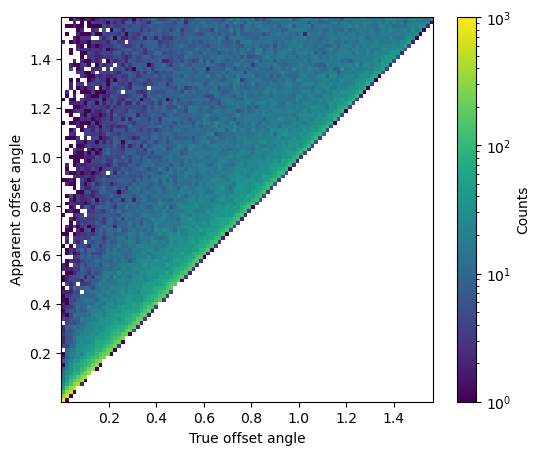

In [3]:
# Simulate N points uniformly distributed within a unit sphere (Monte Carlo),
# then compute each point's "true" 3D offset angle from the disk plane versus
# its "apparent" (projected) offset angle, i.e. what we'd measure in 2D on the sky.
N = 100000
R = 1.0

phi = 2 * np.pi * np.random.random(N)       # random azimuthal angle
costheta = 2 * np.random.random(N) - 1      # uniform in cos(theta) for isotropic sampling on a sphere
u = np.random.random(N)

theta = np.arccos(costheta)
r = R * u**(1/3)                            # uniform volume density within the sphere

# Cartesian coordinates of each simulated point
x = r * np.sin(theta) * np.cos(phi)
y = r * np.sin(theta) * np.sin(phi)
z = r * np.cos(theta)

# True offset angle: angle out of the xy-plane using the full 3D position
true_offset_angle = np.arctan(np.abs(z)/np.sqrt(x**2 + y**2))
# Apparent (projected) offset angle: as it would appear projected onto the x-z plane
apparent_offset_angle = np.arctan(np.abs(z)/np.abs(x))

#plt.scatter(true_offset_angle,apparent_offset_angle,alpha=0.005);

# 2D histogram comparing true vs. apparent offset angle
plt.figure(figsize=(6, 5))
plt.hist2d(true_offset_angle,apparent_offset_angle,bins=100,norm=mpl.colors.LogNorm())
plt.xlabel('True offset angle')
plt.ylabel('Apparent offset angle')
plt.colorbar(label='Counts')
plt.show()

In [4]:
# Convert true/apparent offset angles to degrees and bin by true angle,
# to later look at how much the apparent angle can deviate from the true angle.
true_deg = np.degrees(true_offset_angle)
app_deg  = np.degrees(apparent_offset_angle)

delta_deg = np.abs(app_deg - true_deg)

true_bins = np.linspace(0, 90, 10) 
bin_centers = 0.5 * (true_bins[:-1] + true_bins[1:])

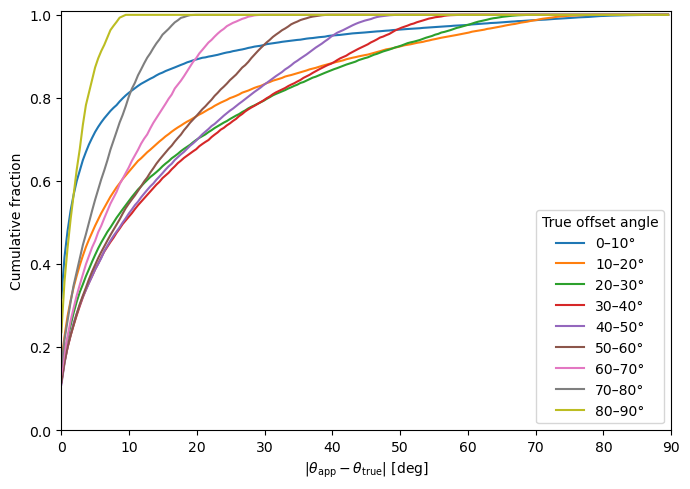

In [5]:
# For each true-angle bin, plot the cumulative distribution of the (absolute)
# difference between apparent and true offset angle -- i.e. how much projection
# effects smear out the true angle for satellites at a given true offset.

delta_max = 90    
delta_bins = np.linspace(0, delta_max, 200)

plt.figure(figsize=(7,5))

for i in range(len(true_bins)-1):
    
    mask = (true_deg >= true_bins[i]) & (true_deg < true_bins[i+1])
    if np.sum(mask) < 1:
        continue  

    hist, edges = np.histogram(delta_deg[mask],bins=delta_bins,density=True)

    cdf = np.cumsum(hist) * np.diff(edges)

    plt.plot(edges[:-1],cdf,label=f'{true_bins[i]:.0f}–{true_bins[i+1]:.0f}°')

#plt.axhline(0.9, color='k', ls='--', lw=1)
#plt.axvline(5, color='k', ls=':', lw=1)

plt.xlabel(r'$|\theta_{\rm app} - \theta_{\rm true}|$ [deg]')
plt.ylabel('Cumulative fraction')
plt.legend(title='True offset angle')
plt.xlim(0, delta_max)
plt.ylim(0, 1.01)
plt.tight_layout()
plt.show()

In [6]:
# Convert to degrees if not already
true_deg = np.degrees(true_offset_angle)
app_deg  = np.degrees(apparent_offset_angle)

# Absolute difference
delta_deg = np.abs(app_deg - true_deg)

# Fraction within 10 degrees
frac_within_10 = np.sum(delta_deg <= 20) / len(delta_deg)

print(f"Fraction of galaxies with apparent angle within 10° of true: {frac_within_10*100:.3f}")

Fraction of galaxies with apparent angle within 10° of true: 77.297


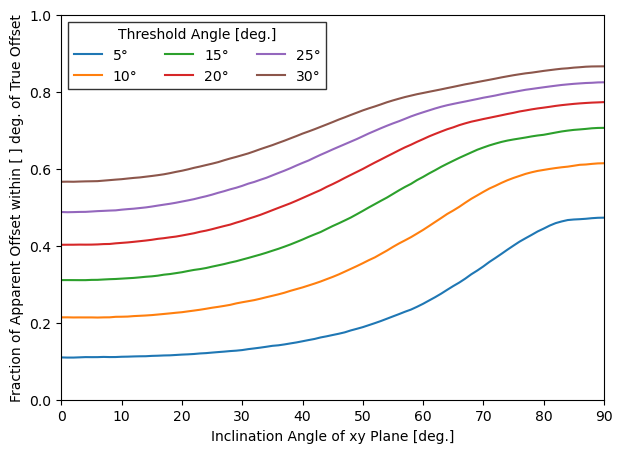

In [7]:
# For a range of inclination angles of the satellite-hosting plane, compute what
# fraction of simulated satellites have an apparent offset angle within a given
# threshold of their true offset angle -- quantifying how projection can bias
# the observed (projected) angle away from the true 3D angle.

inclinations = np.arange(0, 91, 1)
true_deg = np.degrees(true_offset_angle)

plt.figure(figsize=(7,5))

for threshold in [5,10,15,20,25,30]:
    fractions_within_thresh = []
    
    for inc_deg in inclinations:
        inc = np.radians(inc_deg)
        
        # rotate y-z plane by inclination
        x_rot = x
        y_rot = y * np.cos(inc) - z * np.sin(inc)
        z_rot = y * np.sin(inc) + z * np.cos(inc)
        
        # apparent offset angle along projected axes
        app_rot_deg = np.degrees(np.arctan(np.abs(z_rot) / np.abs(x_rot)))
        
        # fraction within threshold degrees
        delta_deg = np.abs(app_rot_deg - true_deg)
        frac = np.sum(delta_deg <= threshold) / len(delta_deg)
        fractions_within_thresh.append(frac)
    
    # plot with label for this threshold
    plt.plot(inclinations, fractions_within_thresh[::-1], label=f'{threshold}°')

plt.xlabel('Inclination Angle of xy Plane [deg.]')
plt.ylabel('Fraction of Apparent Offset within [ ] deg. of True Offset')
plt.xlim(0, 90)
plt.ylim(0, 1)
plt.legend(title='Threshold Angle [deg.]',ncol=3,fancybox=False,edgecolor='k')
plt.show()

## SAGA

Load and process the SAGA survey satellite catalog: combine host + satellite tables, apply sample/quality cuts, and compute each satellite's projected azimuthal (position) angle relative to its host's major axis.

In [8]:
# combine table C1 and C3, attach host properties to each satellite

saga_host_path = 'saga-dr3-tableC1.txt'
saga_sats_path = 'saga-dr3-tableC3.txt'
saga_hosts = Table.read(saga_host_path, format='ascii')
saga_sats = Table.read(saga_sats_path, format = 'ascii')
saga_joined = join(saga_sats, saga_hosts, 'HOSTID', 'left',uniq_col_name='{table_name}{col_name}',table_names=['', 'HOST_'])

print(len(saga_joined))

378


### Filters and Cuts on SAGA Data

In [9]:
# subselect the 3 different samples in the SAGA survey: gold, silver, participation

''' 1 = Gold;
    2 = Silver;
    3 = Participation'''

gold_filter = saga_sats['sample']== 1
silver_filter = saga_sats['sample'] == 2
participation_filter = saga_sats['sample'] == 3

In [10]:
# g-r color selection (use 0.7 as the division)
# where did this choice come from?

gr = np.array(saga_hosts['gr'].data)
blue_filter = gr<0.7
red_filter = gr >0.7


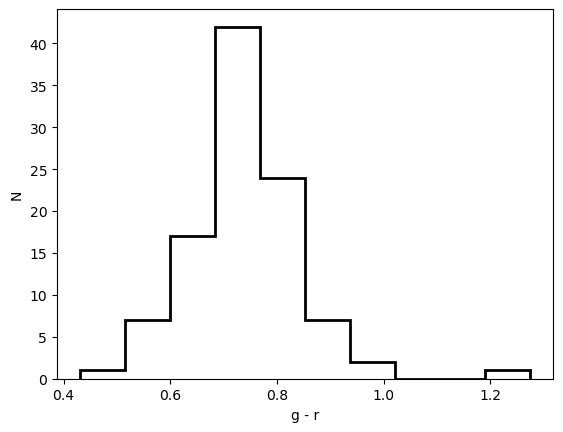

In [11]:
# plot color distribution 

plt.hist(gr,color='k',histtype='step',linewidth=2)
plt.xlabel('g - r')
plt.ylabel('N')
plt.show()

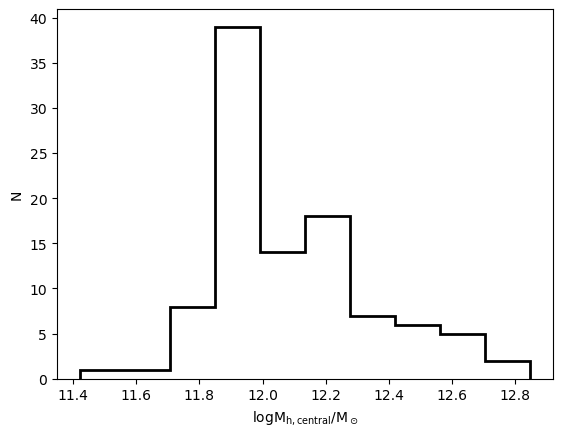

In [12]:
# r200 calculation, from Jingyao

def calc_r200(mhalo, do_print=False):

    import astropy.constants as const
    from astropy.cosmology import Planck18 as cosmo
    import astropy.units as u
    import numpy as np
    import sys


    mhalo = mhalo*u.Msun
    delta = 200 ## rho/rho_crit=200

    # calculate r200 with respect to critical density
    rho_c = cosmo.critical_density0
    r200_c = ((3*mhalo/(4.*np.pi*delta*rho_c))**(1./3.)).to(u.kpc)


    # calculate r200 with respect to matter density
    rho_m = cosmo.critical_density0 * cosmo.Om0
    r200_m = ((3*mhalo/(4.*np.pi*delta*rho_m))**(1./3.)).to(u.kpc)
    
    return r200_c.value, r200_m.value

# load Mhalo and calculate R200
hosts_log_mhalo_array = saga_hosts['log(Mhalo)'].data
r200c,r200m = calc_r200((10**hosts_log_mhalo_array))

# plot halo mass distribution

plt.hist(hosts_log_mhalo_array,color='k',histtype='step',linewidth=2)
plt.xlabel(r'$\mathrm{logM_{h,central}/M_\odot}$')
plt.ylabel('N')
plt.show()

### Calculating Azimuthal Angle from Major Axis

In [13]:
# Inspect the joined satellite table
saga_sats

OBJID,HOSTID,PGC,RAdeg,DEdeg,Rhost,rmag,e_rmag,gr,rmag-fiber,sb,ba,PA,Sersic,TELNAME,z,DVhost,log(M*),EW-Halpha,e_EW-Halpha,log(sfr)Halpha,e_log(sfr)Halpha,NUVmag,e_NUVmag,f_NUVmag,log(sfr)NUV,e_log(sfr)NUV,quenched,log(MHI),HIsource,flux-Halpha,e_flux-Halpha,flux-Hbeta,e_flux-Hbeta,flux-NII,e_flux-NII,flux-OIII,e_flux-OIII,flux-SII6717,e_flux-SII6717,flux-SII6731,e_flux-SII6731,flux-note,sample
,,,deg,deg,kpc,mag,mag,mag,mag,mag / arcsec2,,deg,,,,km / s,dex(Msun),1e-10 m,1e-10 m,dex(Msun / yr),dex(Msun / yr),mag,mag,,dex(Msun / yr),dex(Msun / yr),,dex(Msun),,1e-19 W / (nm m2),1e-19 W / (nm m2),1e-19 W / (nm m2),1e-19 W / (nm m2),1e-19 W / (nm m2),1e-19 W / (nm m2),1e-19 W / (nm m2),1e-19 W / (nm m2),1e-19 W / (nm m2),1e-19 W / (nm m2),1e-19 W / (nm m2),1e-19 W / (nm m2),,
int64,str9,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str5,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,int64,float64,str7,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64
900315730000006229,pgc68312,127631,334.0148085,-64.8787862,216.512,15.586,0.0008,0.465,20.087,21.854,0.678,135.099,1.185,AAT,0.01014,73.321,8.736,12.073,0.3986,-1.544,0.0337,18.508,0.052,1,-1.61,0.0827,0,--,--,1781.456,48.314,570.628,62.299,313.982,33.007,774.563,46.687,461.423,32.208,317.827,27.779,1,1
900316320000001800,pgc1952,-1,8.2736807,-64.6349444,234.685,19.014,0.0065,0.436,22.148,23.336,0.542,0.113,0.839,AAT,0.00859,-49.475,7.187,2.372,0.804,--,--,22.263,0.288,0,-3.257,0.1403,1,--,--,15.442,4.567,2.346,2.018,3.372,3.596,10.537,3.913,1.751,2.549,1.853,3.377,1,2
900322490000007741,pgc1952,1951,8.0041237,-64.3899958,80.501,14.046,0.0002,0.345,19.004,20.943,0.192,113.186,1.366,AAT,0.00916,123.04,9.075,61.071,2.5631,-0.433,0.0361,15.49,0.05,1,-0.548,0.0825,0,--,--,35702.422,580.374,11579.828,408.988,4287.794,404.955,29759.095,965.975,5627.409,401.067,4329.746,367.306,1,1
900328120000004044,pgc68312,68196,332.5294118,-64.5782122,294.065,13.874,0.0002,0.628,19.737,21.468,0.366,48.209,1.065,MIKE,0.00997,22.43,9.6,14.7,0.4,-0.787,0.0331,17.328,0.051,1,-1.138,0.0826,0,--,--,--,--,--,--,--,--,--,--,--,--,--,--,0,1
900328130000003547,pgc68312,322039,333.1089681,-64.5071804,244.484,15.916,0.0006,0.431,18.836,20.65,0.892,140.451,1.665,AAT,0.00937,-157.52,8.567,37.049,1.3828,-1.242,0.035,17.998,0.051,1,-1.405,0.0826,0,--,--,3936.819,48.259,1290.943,36.41,385.725,36.526,2928.618,91.54,554.457,35.047,408.554,35.277,1,1
900328140000005155,pgc68312,-1,333.8210676,-64.5983783,236.665,18.469,0.0065,0.625,23.162,24.535,0.794,-8.997,0.838,COADD,0.00917,-218.003,7.759,-3.515,1.8081,--,--,21.715,4.131,0,-2.892,1.6543,1,--,--,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1
900335040000000543,pgc1952,-1,7.9480205,-64.0995786,91.959,19.714,0.0064,0.364,22.25,23.426,0.579,48.339,1.0,AAT,0.00881,16.479,6.828,16.704,1.2187,-3.22,0.042,22.397,0.276,0,-3.31,0.1363,0,--,--,45.294,2.624,13.633,3.303,4.697,1.513,20.835,4.777,5.507,1.656,3.953,0.976,1,2
900335040000004860,pgc1952,-1,8.178446,-64.0559986,124.203,19.195,0.0034,0.556,21.338,22.338,0.736,0.908,0.91,AAT,0.00853,-67.462,7.247,-0.979,0.6117,--,--,23.547,0.655,0,-3.77,0.2739,1,--,--,11.149,3.167,1.907,1.569,1.716,1.877,25.764,4.752,3.222,1.384,2.984,1.173,1,2


In [14]:
# calculate angle

saga_PA = np.zeros(len(saga_sats))
saga_quenched = saga_sats['quenched'].data
for m in range(len(saga_hosts)):
    h_c = SkyCoord(saga_hosts['RAdeg'][m],saga_hosts['DEdeg'][m], frame = "icrs", unit = "deg")
    
    for n in range(len(saga_sats)):

        if saga_hosts['HOSTID'][m] == saga_sats['HOSTID'][n]:

            PA = saga_hosts['PA'][m]
            s_c = SkyCoord(saga_sats['RAdeg'][n],saga_sats['DEdeg'][n], frame = "icrs", unit = "deg")
            relative_angle = h_c.position_angle(s_c).degree
            #print(relative_angle)
            relative_angle_corrected = 90 + relative_angle
            #PA_central = customSimbad.query_object(saga_hosts['HOSTID'][m])['GALDIM_ANGLE'].value
            #print((90 - PA) + relative_angle)
            angle_final = ((90 - PA) + relative_angle_corrected)%360
            saga_PA[n] = angle_final

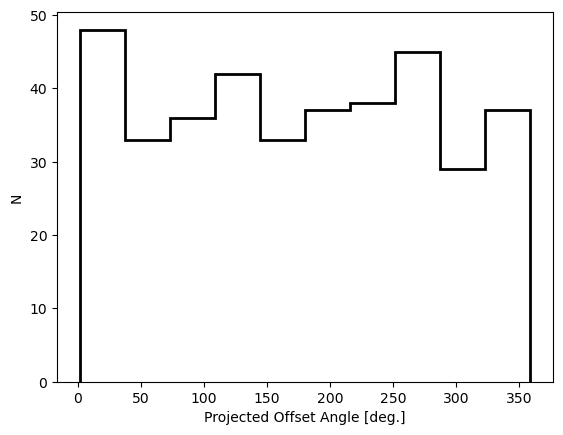

In [15]:
# plot angle distribution

plt.hist(saga_PA,color='k',histtype='step',linewidth=2)
plt.xlabel(r'Projected Offset Angle [deg.]')
plt.ylabel('N')
plt.show()

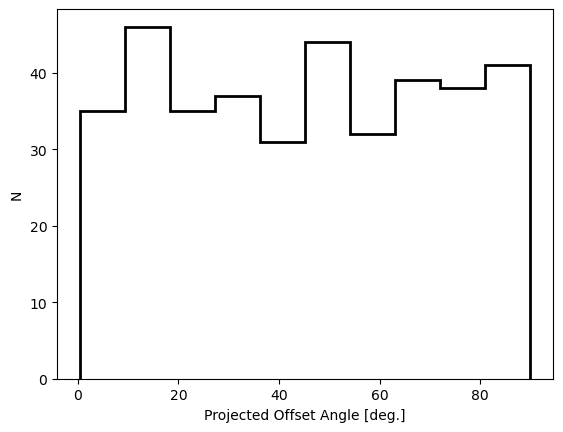

In [16]:
# convert to 0-90

def map_to_0_90(angles):

    angles = np.mod(angles, 360)
    return np.where(angles <= 90, angles,  
           np.where(angles <= 180, 180 - angles,  
           np.where(angles <= 270, angles - 180,  
                    360 - angles))) 

# plot angle distribution

plt.hist(map_to_0_90(saga_PA),color='k',histtype='step',linewidth=2)
plt.xlabel(r'Projected Offset Angle [deg.]')
plt.ylabel('N')
plt.show()

In [17]:
# apply radius limit 

#lmc_limit = saga_sats_gmag < 19

r200c_hosts = np.zeros(len(saga_sats))
r200m_hosts = np.zeros(len(saga_sats))

sats_rhost_array = saga_sats['Rhost'].data

host_data = {saga_hosts['HOSTID'][i]: hosts_log_mhalo_array[i] for i in range(len(saga_hosts))}

# Iterate over the satellites in saga_sats, and match each with its host using HOSTID
for i in range(len(saga_sats)):
    host_id = saga_sats['HOSTID'][i]  # Get the host ID of the current satellite
    # Check if the host exists in saga_hosts
    if host_id in host_data:
        host_mhalo = host_data[host_id]  # Get the host distance 
        mhalo = 10**host_mhalo #since the mhalo is given as the logarithm
        r200c,r200m = calc_r200(mhalo)
        r200c_hosts[i] = r200c
         
radius_limit = sats_rhost_array < r200c_hosts

In [18]:
# make a few different subselections:

sample = np.array(saga_sats['sample'])

index1 = (sats_rhost_array < r200c_hosts) & (sample == 1.)
index2 = (sats_rhost_array < r200c_hosts) & (sample == 2.)
index3 = (sats_rhost_array < r200c_hosts) & (sample == 3.)

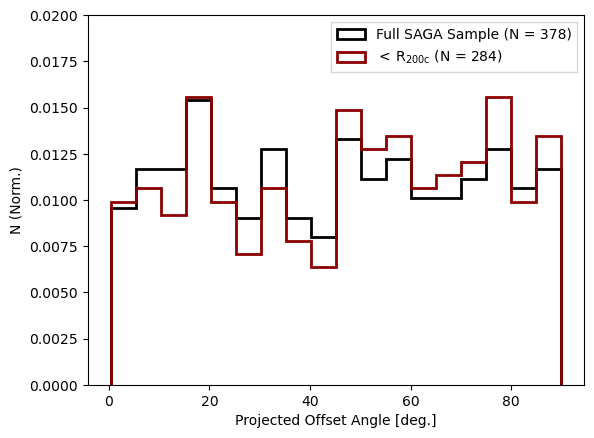

In [19]:
# compare entire SAGA sample with different subselections 

plt.hist(map_to_0_90(saga_PA),color='k',histtype='step',linewidth=2, density = True, bins = 18, label = r'Full SAGA Sample (N = %i)'%len(saga_PA))
plt.hist(map_to_0_90(saga_PA[radius_limit]),color='darkred',histtype='step',linewidth=2, density = True, bins = 18, label = r'$\mathrm{<\,R_{200c}}$ (N = %i)'%len(saga_PA[radius_limit]))

plt.xlabel(r'Projected Offset Angle [deg.]')
plt.ylabel('N (Norm.)')
plt.legend(loc='upper right', fancybox = False)

plt.ylim(0,0.020)

plt.show()

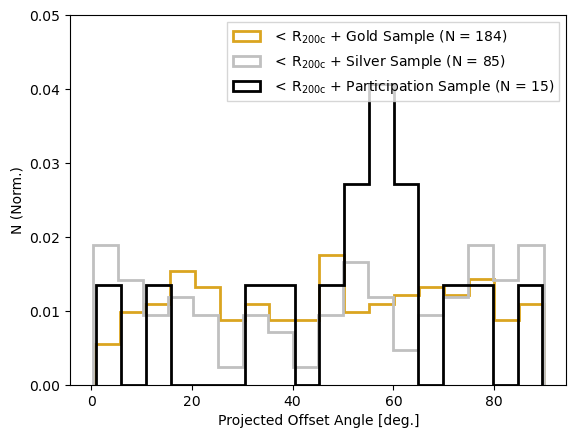

In [20]:
# compare entire SAGA sample with different subselections 

#plt.hist(map_to_0_90(saga_PA),color='k',histtype='step',linewidth=2, density = True, bins = 18, label = r'Full SAGA Sample (N = %i)'%len(saga_PA))
plt.hist(map_to_0_90(saga_PA[index1]),color='goldenrod',histtype='step',linewidth=2, density = True, bins = 18, label = r'$\mathrm{<\,R_{200c}}$ + Gold Sample (N = %i)'%len(saga_PA[index1]))
plt.hist(map_to_0_90(saga_PA[index2]),color='silver',histtype='step',linewidth=2, density = True, bins = 18, label = r'$\mathrm{<\,R_{200c}}$ + Silver Sample (N = %i)'%len(saga_PA[index2]))
plt.hist(map_to_0_90(saga_PA[index3]),color='k',histtype='step',linewidth=2, density = True, bins = 18, label = r'$\mathrm{<\,R_{200c}}$ + Participation Sample (N = %i)'%len(saga_PA[index3]))

plt.xlabel(r'Projected Offset Angle [deg.]')
plt.ylabel('N (Norm.)')
plt.legend(loc='upper right', fancybox = False)

plt.ylim(0,0.050)

plt.show()

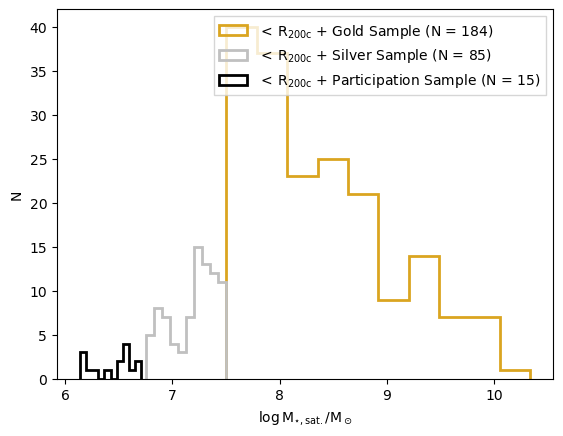

In [21]:
# compare the different SAGA samples (based on satellite stellar mass)

saga_mstar = saga_sats['log(M*)']

plt.hist(saga_mstar[index1],color='goldenrod',histtype='step',linewidth=2, density =False, label = r'$\mathrm{<\,R_{200c}}$ + Gold Sample (N = %i)'%len(saga_mstar[index1]))
plt.hist(saga_mstar[index2],color='silver',histtype='step',linewidth=2, density =False, label = r'$\mathrm{<\,R_{200c}}$ + Silver Sample (N = %i)'%len(saga_mstar[index2]))
plt.hist(saga_mstar[index3],color='k',histtype='step',linewidth=2, density =False, label = r'$\mathrm{<\,R_{200c}}$ + Participation Sample (N = %i)'%len(saga_mstar[index3]))

plt.xlabel(r'$\mathrm{log\, M_{\star,sat.}/M_\odot}$')
plt.ylabel('N')
plt.legend(loc='upper right', fancybox = False)

#plt.ylim(0,0.050)

plt.show()

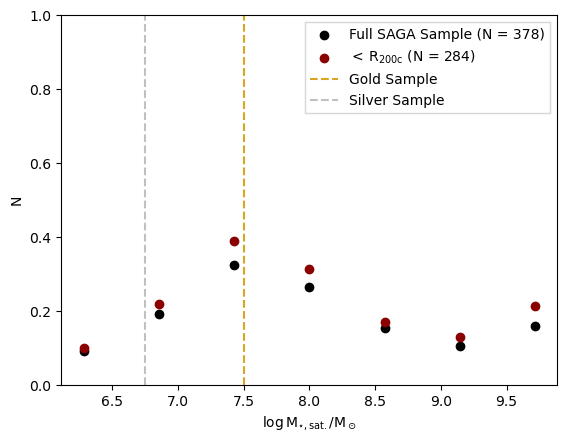

In [22]:
quenched = np.array(saga_sats['quenched'])

q_frac, bin_edges, binnumber = scipy.stats.binned_statistic(saga_mstar,quenched,statistic='mean',bins=7,range=[6,10])
plt.scatter((bin_edges[:-1]+bin_edges[1:])/2,q_frac,color='black', label = r'Full SAGA Sample (N = %i)'%len(saga_PA))

q_frac, bin_edges, binnumber = scipy.stats.binned_statistic(saga_mstar[radius_limit],quenched[radius_limit],statistic='mean',bins=7,range=[6,10])
plt.scatter((bin_edges[:-1]+bin_edges[1:])/2,q_frac,color='darkred', label = r'$\mathrm{<\,R_{200c}}$ (N = %i)'%len(saga_PA[radius_limit]))

plt.axvline(7.5,ls='--',color='goldenrod',label='Gold Sample')
plt.axvline(6.75,ls='--',color='silver',label='Silver Sample')
 
plt.xlabel(r'$\mathrm{log\, M_{\star,sat.}/M_\odot}$')
plt.ylabel('N')
plt.legend(loc='upper right', fancybox = False)
plt.ylim(0,1)
plt.show()

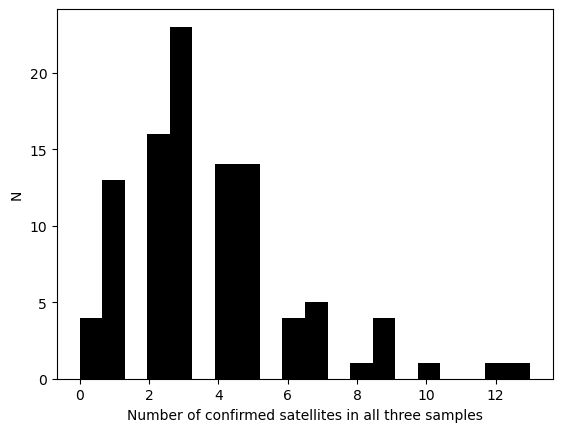

[0 0 0 0]


In [23]:
# there are 4 hosts with no satellites
# nsat-GSPc = Number of confirmed satellites in all three samples: Gold, Silver, Participation

plt.hist(saga_hosts['nsat-GSPc'],bins=20,color='k')
plt.xlabel(r'Number of confirmed satellites in all three samples')
plt.ylabel('N')

plt.show()

print(np.array(saga_hosts['nsat-GSPc'])[np.array(saga_hosts['nsat-GSPc']) == 0])

In [24]:
# there are 16 hosts in the Gold sample with no Gold sample mass (logM > 7.5) satellites 

len(saga_hosts['nsat-Gc'][saga_hosts['nsat-Gc'] == 0])

16

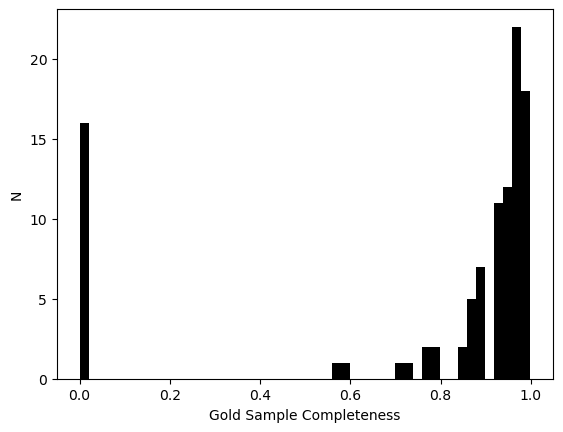

In [25]:
# Gold sample completeness

plt.hist(saga_hosts['nsat-Gc']/saga_hosts['nsat-G'],bins=50,color='k')
plt.xlabel(r'Gold Sample Completeness')
plt.ylabel('N')

plt.show()

In [26]:
# (numpy/astropy already imported in Setup above; this cell was originally standalone)
import astropy.units as u

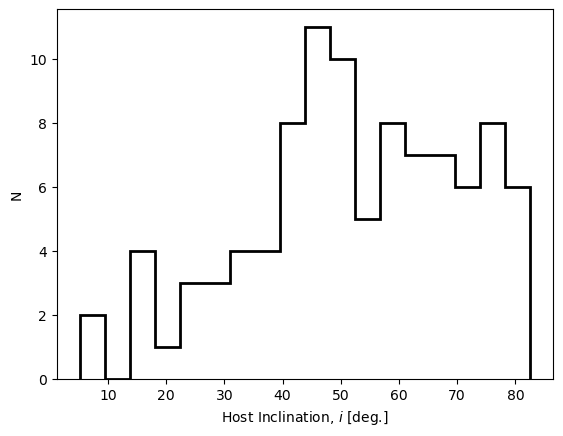

In [27]:
# Host inclination angle from axis ratio (b/a) in the SAGA host table
hostid, idx = np.unique(saga_joined['HOSTID'],return_index=True)
host_ba = saga_joined['HOST_ba'][idx]
host_inclination = (np.arccos(host_ba)*u.rad).to('deg')

plt.hist(host_inclination,color='k',histtype='step', bins = 18, linewidth=2, density =False)

plt.xlabel(r'Host Inclination, $i$ [deg.]')
plt.ylabel('N')
#plt.legend(loc='upper right', fancybox = False)
#plt.ylim(0,1)
plt.show()

In [28]:
# Recompute host inclination for the full joined table (not just unique hosts)
host_ba = saga_joined['HOST_ba']
host_inclination = np.array((np.arccos(host_ba)*u.rad).to('deg'))

index_inclination = (host_inclination >= 0)

index_inclination_ids = np.array(saga_joined['HOSTID'])[index_inclination]

In [29]:
# make a few different subselections:

index_inclination_ids = np.array(saga_joined['HOSTID'])[index_inclination]

HOSTID = np.array(saga_sats['HOSTID'])

index1 = (sats_rhost_array < r200c_hosts) & ((sample == 1.) | (sample == 1.))  & (np.isin(HOSTID,index_inclination_ids))
#index2 = (sats_rhost_array < r200c_hosts) & (sample == 2.)
#index3 = (sats_rhost_array < r200c_hosts) & (sample == 3.)

In [30]:
print('number of SAGA hosts =',len(np.unique(saga_sats['HOSTID'][index1])))
print('number of SAGA satellites =',len(np.unique(saga_PA[index1])))

number of SAGA hosts = 78
number of SAGA satellites = 184


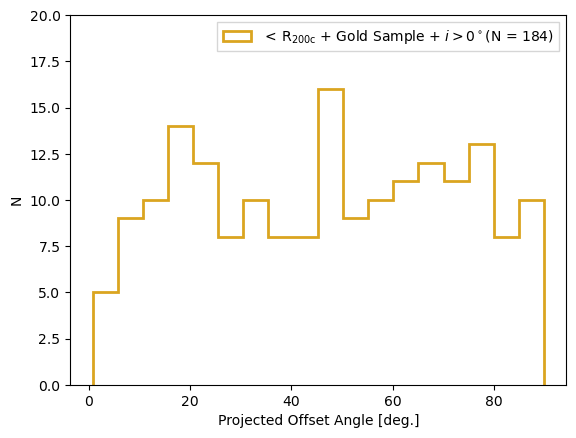

In [31]:
# compare entire SAGA sample with different subselections 

plt.hist(map_to_0_90(saga_PA[index1]),color='goldenrod',histtype='step',linewidth=2, density = False, bins = 18, label = r'$\mathrm{<\,R_{200c}}$ + Gold Sample + $i > 0^\circ$(N = %i)'%len(saga_PA[index1]))
#plt.hist(map_to_0_90(saga_PA[index2]),color='silver',histtype='step',linewidth=2, density = True, bins = 18, label = r'$\mathrm{<\,R_{200c}}$ + Silver Sample (N = %i)'%len(saga_PA[index2]))
#plt.hist(map_to_0_90(saga_PA[index3]),color='k',histtype='step',linewidth=2, density = True, bins = 18, label = r'$\mathrm{<\,R_{200c}}$ + Participation Sample (N = %i)'%len(saga_PA[index3]))

plt.xlabel(r'Projected Offset Angle [deg.]')
plt.ylabel('N')
plt.legend(loc='upper right', fancybox = False)

plt.ylim(0,20)

plt.show()

In [32]:
# final sample, where we only select satellites within r200c of the host galaxy

#saga_PA = saga_PA[radius_limit]
#saga_quenched = saga_quenched[radius_limit]

saga_PA_raw = saga_PA.copy()
saga_quenched_raw = saga_quenched.copy()

saga_PA = saga_PA[index1]
saga_90 = map_to_0_90(saga_PA)
saga_quenched = saga_quenched[index1]

## Importing and Processing ELVES

Load the ELVES host and confirmed-satellite catalogs, query SIMBAD for host position angle / inclination, and compute each satellite's projected offset angle (mirroring the SAGA procedure above).

In [33]:
# import ELVES data 

sats = pd.read_csv('Carlsten22_ELVES_confirmed_sats - Carlsten22_ELVES_confirmed_sats_compre.csv')
hosts_unfiltered = pd.read_csv(
    "Carlsten22_ELVES_host - Carlsten22_ELVES_host.csv",
    skipfooter=1,
    engine="python",
)

s_host = pd.read_csv("saga_host_compre.csv")

In [34]:
# Inspect loaded ELVES host table
hosts_unfiltered

,Host,Early_type_host?,Inclination,Position_angle,Host_with_sat_mask,Host_early_type_mask,Host_group_primary_mask,Host_alfa_overlap_mask,Host_r200_coverage_mask,Host_r200_half_coverage_mask,...,R200,Vesc(R200),Netg,Netg_r200,Netg_dim,Netg_dim_r200,Ngas,Ngas_r200,Ngas_dim,Ngas_dim_r200
0,M31,NaN,NaN,NaN,0,0,0,0,0,1,...,379.360431,362.993644,0,0,0,0,0,0,0,0
1,NGC253,NaN,NaN,NaN,1,0,0,0,1,1,...,275.555240,263.666932,2,2,2,2,3,2,2,2
2,NGC628,NaN,NaN,NaN,1,0,0,0,1,1,...,208.146720,199.166624,5,5,5,5,8,4,8,4
3,NGC891,NaN,NaN,NaN,1,0,0,0,0,1,...,299.281096,286.369181,2,2,2,2,1,1,1,1
4,NGC1023,True,NaN,NaN,1,1,0,0,0,1,...,233.492820,223.419215,6,6,6,6,8,8,7,7
5,NGC1291,NaN,NaN,NaN,1,0,0,0,1,1,...,278.670684,266.647966,11,11,11,11,3,3,3,3
6,NGC1808,NaN,NaN,NaN,1,0,0,0,1,1,...,161.977614,154.989397,6,4,6,4,4,4,2,2
7,NGC2683,NaN,NaN,NaN,1,0,0,0,1,1,...,215.729695,206.422447,4,3,4,3,2,2,2,2
8,NGC2903,NaN,NaN,NaN,1,0,0,1,1,1,...,248.620050,237.893809,3,2,3,2,4,4,4,4
9,M81,NaN,NaN,NaN,0,0,1,0,1,1,...,246.295078,235.669144,0,0,0,0,0,0,0,0


In [35]:
# Inspect loaded ELVES satellite table
sats

,Host,Sat_name,RA(deg),DEC(deg),D_SBF(Mpc),D_TRGB(Mpc),Vel(km/s),dvel,Rproj(kpc),Rproj_in_Rvir?,Theta,ETG?,M_g,lgM_star
0,NGC253,NGC247,11.783,-20.757,NaN,3.72,159.0,-100.0,282.2,0,1.092086,0,-18.31,9.41
1,NGC253,dw0047m2623,11.894,-26.390,NaN,3.90,NaN,NaN,68.5,1,NaN,1,-8.86,5.77
2,NGC253,dw0049m2100,12.454,-21.017,NaN,3.44,295.0,36.0,267.9,1,0.981759,0,-12.69,6.62
3,NGC253,dw0050m2444,12.575,-24.737,NaN,3.12,NaN,NaN,51.7,1,NaN,1,-9.53,5.53
4,NGC253,dw0055m2309,13.754,-23.169,NaN,NaN,250.0,-9.0,169.0,1,0.614256,0,-10.26,5.95
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
246,NGC6744,dw1905m6316,286.483,-63.272,7.61,NaN,NaN,NaN,113.2,1,NaN,1,-11.44,6.70
247,NGC6744,dw1906m6357,286.742,-63.964,7.31,NaN,NaN,NaN,50.9,1,NaN,1,-13.33,7.46
248,NGC6744,dw1907m6342,286.844,-63.706,7.99,NaN,NaN,NaN,47.6,1,NaN,1,-11.88,6.71
249,NGC6744,dw1908m6343,287.183,-63.730,5.33,NaN,NaN,NaN,26.7,1,NaN,0,-15.21,7.68


In [36]:
from astroquery.simbad import Simbad

customSimbad = Simbad()
customSimbad.reset_votable_fields()
# Add degree-valued RA/DEC + host PA
customSimbad.add_votable_fields('ra', 'dec', 'galdim_angle','galdim_majaxis','galdim_minaxis')


In [37]:
# Spot-check host name column
hosts_unfiltered['Host']

0         M31
1      NGC253
2      NGC628
3      NGC891
4     NGC1023
5     NGC1291
6     NGC1808
7     NGC2683
8     NGC2903
9         M81
10    NGC3115
11    NGC3344
12    NGC3379
13    NGC3521
14    NGC3556
15    NGC3621
16    NGC3627
17    NGC4258
18    NGC4517
19    NGC4565
20       M104
21    NGC4631
22    NGC4736
23    NGC4826
24    NGC5055
25      CEN A
26    NGC5194
27    NGC5236
28    NGC5457
29    NGC6744
Name: Host, dtype: object

In [38]:
# get position angle from ELVES hosts 
# NOTE: this is a first-pass computation of host inclination/PA via SIMBAD;
# it gets refined below (see 'Recompute Inclination Angle with new filter').

hosts_missing_pa = []
pa_val = []
elves_inclination = []
elves_PA = []
pa_indices = []


for i, host in enumerate(hosts_unfiltered['Host']):
    tab = customSimbad.query_object(host)

    val = tab['galdim_angle']
    major_axis = tab['galdim_majaxis'].value
    minor_axis = tab['galdim_minaxis'].value
    
    #print(val[0])
    pa_val.append(val.value)
    if np.ma.is_masked(val):
        hosts_missing_pa.append(host)
    else:
        pa_indices.append(i)
        print(hosts_unfiltered['Host'][i])
        print("major_axis:", major_axis)
        print("minor_axis:", minor_axis)
        #print(' d')
        inclination_angle = np.arccos((minor_axis)/(major_axis))*180/np.pi
        print("inclination_angle:", inclination_angle)
        elves_inclination.append(inclination_angle)
        elves_PA.append(val)

hosts  = hosts_unfiltered.iloc[pa_indices].copy()
#print("Hosts missing GALDIM_ANGLE:")
#for h in hosts_missing_pa:
    #print(h)
    #print(customSimbad.query_object(h)['galdim_angle'])


M31
major_axis: [199.52999877929688]
minor_axis: [70.79000091552734]
inclination_angle: [69.21981048583984]


NGC253
major_axis: [28.84000015258789]
minor_axis: [5.889999866485596]
inclination_angle: [78.2155532836914]
NGC628
major_axis: [6.703949928283691]
minor_axis: [6.6529998779296875]
inclination_angle: [7.068383693695068]


NGC891
major_axis: [12.300000190734863]
minor_axis: [2.450000047683716]
inclination_angle: [78.51057434082031]


NGC1291
major_axis: [10.470000267028809]
minor_axis: [8.130000114440918]
inclination_angle: [39.05838394165039]
NGC1808
major_axis: [9.99761962890625]
minor_axis: [3.788100004196167]
inclination_angle: [67.73442077636719]


NGC2683
major_axis: [8.710000038146973]
minor_axis: [2.569999933242798]
inclination_angle: [72.83867645263672]
NGC2903
major_axis: [8.858909606933594]
minor_axis: [4.617269992828369]
inclination_angle: [58.5871696472168]


...

NGC4565
major_axis: [13.800000190734863]
minor_axis: [2.190000057220459]
inclination_angle: [80.86880493164062]
M104
major_axis: [8.510000228881836]
minor_axis: [5.010000228881836]
inclination_angle: [53.93383026123047]


NGC4631
major_axis: [16.56209945678711]
minor_axis: [3.13850998878479]
inclination_angle: [79.076416015625]
NGC4736
major_axis: [6.990779876708984]
minor_axis: [5.861070156097412]
inclination_angle: [33.0284423828125]


NGC4826
major_axis: [10.993399620056152]
minor_axis: [6.22445011138916]
inclination_angle: [55.51441955566406]
NGC5055
major_axis: [13.180000305175781]
minor_axis: [7.940000057220459]
inclination_angle: [52.956016540527344]


CEN A
major_axis: [25.700000762939453]
minor_axis: [17.780000686645508]
inclination_angle: [46.224952697753906]
NGC5194
major_axis: [9.043789863586426]
minor_axis: [7.783989906311035]
inclination_angle: [30.60472869873047]


NGC6744
major_axis: [17.3799991607666]
minor_axis: [10.960000038146973]
inclination_angle: [50.90486145019531]


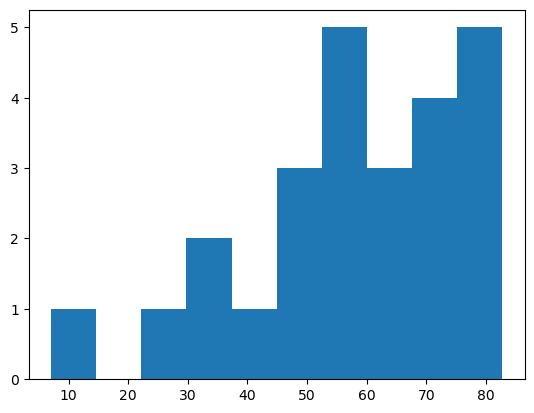

In [39]:
# Quick look at the distribution of host inclinations from the first-pass query above
plt.hist(np.array(elves_inclination), linewidth=2, density =False)
plt.show()

In [40]:
# Manual inclination notes/spot-checks for a few hosts gathered from NED
# (kept as a reference / sanity-check, not used programmatically below).
"""NGC1023, 90  # https://ned.ipac.caltech.edu/byname?objname=NGC1023&hconst=67.8&omegam=0.308&omegav=0.692&wmap=4&corr_z=1
NGC3379, spherical: 90 or 0  # https://ned.ipac.caltech.edu/byname?objname=NGC3379&hconst=67.8&omegam=0.308&omegav=0.692&wmap=4&corr_z=1
NGC4258, 150 # https://ned.ipac.caltech.edu/byname?objname=NGC4258&hconst=67.8&omegam=0.308&omegav=0.692&wmap=4&corr_z=1
NGC5236, face-on: 0 # https://ned.ipac.caltech.edu/byname?objname=NGC5236&hconst=67.8&omegam=0.308&omegav=0.692&wmap=4&corr_z=1
NGC5457, also face-on # https://ned.ipac.caltech.edu/byname?objname=NGC5457&hconst=67.8&omegam=0.308&omegav=0.692&wmap=4&corr_z=1"""

'NGC1023, 90  # https://ned.ipac.caltech.edu/byname?objname=NGC1023&hconst=67.8&omegam=0.308&omegav=0.692&wmap=4&corr_z=1\nNGC3379, spherical: 90 or 0  # https://ned.ipac.caltech.edu/byname?objname=NGC3379&hconst=67.8&omegam=0.308&omegav=0.692&wmap=4&corr_z=1\nNGC4258, 150 # https://ned.ipac.caltech.edu/byname?objname=NGC4258&hconst=67.8&omegam=0.308&omegav=0.692&wmap=4&corr_z=1\nNGC5236, face-on: 0 # https://ned.ipac.caltech.edu/byname?objname=NGC5236&hconst=67.8&omegam=0.308&omegav=0.692&wmap=4&corr_z=1\nNGC5457, also face-on # https://ned.ipac.caltech.edu/byname?objname=NGC5457&hconst=67.8&omegam=0.308&omegav=0.692&wmap=4&corr_z=1'

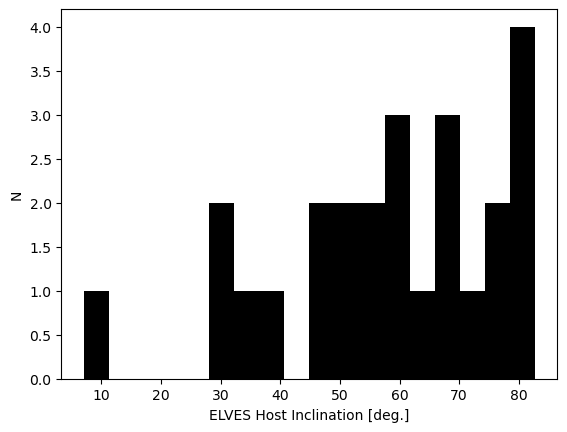

In [41]:
# plot ELVES host inclination

elves_inclination_reformat = np.concatenate([c.filled(np.nan) for c in elves_inclination])
elves_PA_reformat = np.concatenate([c.astype(float).filled(np.nan) for c in elves_PA])

plt.hist(elves_inclination_reformat,color='k',bins=18)
plt.xlabel("ELVES Host Inclination [deg.]")
plt.ylabel("N")
plt.show()

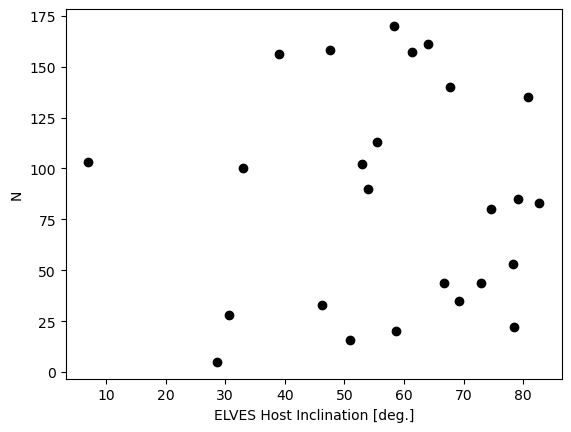

In [42]:
# Sanity check: host inclination vs. position angle (first-pass values)
plt.scatter(elves_inclination_reformat,elves_PA_reformat,color='k')
plt.xlabel("ELVES Host Inclination [deg.]")
plt.ylabel("N")
plt.show()

In [43]:
# Refine the host list to only those with a valid (unmasked) position angle from SIMBAD
valid_indices = []

for i, host in enumerate(hosts_unfiltered['Host']):
    tab = customSimbad.query_object(host)
    val = tab['galdim_angle']

    if not np.ma.is_masked(val):  # keep only if PA exists
        valid_indices.append(i)

# Keep only rows with valid PA
hosts = hosts_unfiltered.iloc[valid_indices].copy()

In [44]:
# Recompute the final ELVES satellite position angles -- this elves_PA is the one
# actually used throughout the rest of the notebook, analogous to the SAGA PA calc.
import numpy as np
from astropy.coordinates import SkyCoord

pa_list, dproj_list, mass_list = [], [], []
kept_indices = []  # optional: lets you map back to rows in `sats`

for r in range(len(sats)):
    host = sats['Host'].get(r)

    # Query host once each place we need
    h_table = Simbad.query_object(host)
    pa_tab  = customSimbad.query_object(host)

    # Skip if PA is missing/masked
    pa_col = pa_tab['galdim_angle']
    if np.ma.is_masked(pa_col):
        continue

    # Build coords (skip if satellite coords missing)
    try:
        h_coords = SkyCoord(ra=h_table['ra'], dec=h_table['dec'], frame='icrs')
        s_coords = SkyCoord(ra=sats['RA(deg)'].get(r),
                            dec=sats['DEC(deg)'].get(r),
                            frame='icrs', unit='deg')
    except Exception:
        # If any coord is malformed, skip this row
        continue

    position_angle = h_coords.position_angle(s_coords).degree

    # Compute the angle using GALDIM_ANGLE value
    angle = ((90 - pa_col.value) + position_angle + 90) % 360

    # Append valid values
    pa_list.append(angle)
    dproj_list.append(sats['Rproj(kpc)'].get(r))
    mass_list.append(sats['lgM_star'].get(r))
    kept_indices.append(r)

# Final arrays contain ONLY rows with valid PA
elves_PA    = np.array(pa_list, dtype=float)
elves_dproj = np.array(dproj_list, dtype=float)
elves_mass  = np.array(mass_list, dtype=float)

#### Recompute Inclination Angle with new filter

In [45]:
# Recompute host inclination using the refined host list (`hosts`) from above.
hosts_missing_pa, pa_val, elves_inclination, elves_PA_host, pa_indices = [], [], [], [], []

for i in range(len(hosts)):
    host = hosts["Host"].iloc[i]
    tab = customSimbad.query_object(host)

    val = tab["galdim_angle"]
    major_axis = tab["galdim_majaxis"].value
    minor_axis = tab["galdim_minaxis"].value

    pa_val.append(val.value)
    if np.ma.is_masked(val):
        hosts_missing_pa.append(host)
    else:
        pa_indices.append(i)
        print(host)
        inclination_angle = np.degrees(np.arccos(minor_axis / major_axis))
        elves_inclination.append(inclination_angle)
        elves_PA_host.append(val)


M31
NGC253
NGC628
NGC891
NGC1291
NGC1808
NGC2683
NGC2903
M81
NGC3115
NGC3344
NGC3521
NGC3556
NGC3621
NGC3627
NGC4517
NGC4565
M104
NGC4631
NGC4736
NGC4826
NGC5055
CEN A
NGC5194
NGC6744


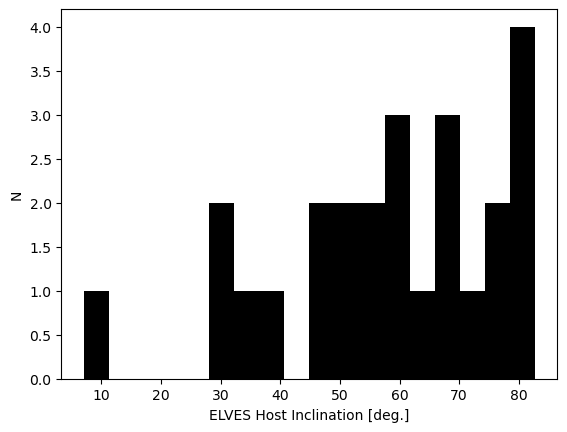

In [46]:
# plot ELVES host inclination

elves_inclination_reformat = np.concatenate([c.filled(np.nan) for c in elves_inclination])
elves_PA_reformat = np.concatenate([c.astype(float).filled(np.nan) for c in elves_PA_host])

plt.hist(elves_inclination_reformat,color='k',bins=18)
plt.xlabel("ELVES Host Inclination [deg.]")
plt.ylabel("N")
plt.show()

In [47]:
# Number of hosts with a usable inclination measurement
print(len(elves_inclination))

25


In [48]:
#elves position angles

n_theta = np.zeros(len(elves_PA))  
    
for n in range(len(elves_PA)):
    angle_val = float(elves_PA[n]) 
    if angle_val > 180:
        n_theta[n] = (180 - (angle_val % 180))
    else: 
        n_theta[n] = angle_val
        
#sats_filter =  (sats['lgM_star']<(10**10))&(sats['Rproj_in_Rvir?']==1)


/var/folders/52/r93wsrcx1b3cnhc1tg56pl240000gn/T/ipykernel_43944/3444517990.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  angle_val = float(elves_PA[n])


In [49]:
#elves quench values
elves_quenched = sats['ETG?'].iloc[kept_indices]
elves_PA = elves_PA

In [50]:
# Sanity check on the SAGA joined-table length
print(len(saga_joined))

378


In [51]:
# Summary counts for the final ELVES sample
print('number of ELVES hosts =',len(hosts))
print('number of ELVES satellites =',len(elves_PA))

number of ELVES hosts = 25
number of ELVES satellites = 177


# Working with Both ELVES and SAGA

Combine the processed SAGA and ELVES samples to compare their satellite angular distributions and quenched fractions.

### Quench Fraction Calculation

In [52]:
# NOTE: superseded by the redefinition of `quenched_fraction_with_bootstrap` in the
# next cell -- Python overwrites this version, so it has no effect at runtime.
# Kept here for reference on an earlier windowing approach.

def bootstrap_error(data, n_bootstrap=10000):
    if len(data) == 0:
        return 0.0
    bootstraps = np.random.choice(data, size=(n_bootstrap, len(data)), replace=True)
    means = np.nanmean(bootstraps, axis=1)
    return np.std(means)
    
def quenched_fraction_with_bootstrap(angles, quenching, bin_size, window_size, angle_range=(0, 90), n_bootstrap=10000):
    
    angles = np.asarray(angles).flatten()
    quenching = np.asarray(quenching, dtype=float).flatten()
    
    centers = [] 
    means = []
    errors = []

    center_value = angle_range[0] + window_size
    
    while center_value <= angle_range[1] - window_size:

        # Define window: angles within [center - window_size, center + window_size)
        in_window = (angles >= center_value - window_size) & (angles < center_value + window_size)
        values_in_window = quenching[in_window]

        # Store center
        centers.append(center_value)

        # Compute moving mean and bootstrap error
        means.append(np.nanmean(values_in_window))
        errors.append(bootstrap_error(values_in_window, n_bootstrap=n_bootstrap))

        # Move to next window center
        center_value += bin_size
        
    return np.array(centers), np.array(means), np.array(errors)

In [53]:
# Active version of `quenched_fraction_with_bootstrap` (overrides the previous cell).
# Uses a fixed +/-2.5 deg window stepped every 5 deg, regardless of the
# bin_size/window_size arguments passed by the caller.

def bootstrap_error(data, n_bootstrap=10000):
    if len(data) == 0:
        return 0.0
    bootstraps = np.random.choice(data, size=(n_bootstrap, len(data)), replace=True)
    means = np.nanmean(bootstraps, axis=1)
    return np.std(means)
    
def quenched_fraction_with_bootstrap(angles, quenching, bin_size, window_size, angle_range=(0, 90), n_bootstrap=10000):
    
    angles = np.asarray(angles).flatten()
    quenching = np.asarray(quenching, dtype=float).flatten()
    
    centers = [] 
    means = []
    errors = []

    center_value = angle_range[0] + 2.5
    
    while center_value < 90:

        # Define window: angles within [center - window_size, center + window_size)
        in_window = (angles >= center_value - 2.5) & (angles < center_value + 2.5)
        values_in_window = quenching[in_window]

        # Store center
        centers.append(center_value)

        # Compute moving mean and bootstrap error
        means.append(np.nanmean(values_in_window))
        #print(len(values_in_window))
        errors.append(bootstrap_error(values_in_window, n_bootstrap=n_bootstrap))

        # Move to next window center
        center_value += 5
        
    return np.array(centers), np.array(means), np.array(errors)

In [54]:
#saga data
saga_bins, saga_quench, saga_error = quenched_fraction_with_bootstrap(saga_90, saga_quenched, 5, 5)

In [55]:
# elves data
elves_90 = map_to_0_90(elves_PA)
elves_bins, elves_quench, elves_error = quenched_fraction_with_bootstrap(elves_90, elves_quenched,5,5)
elves_90_correct = []
for i in range(len(elves_90)):
    elves_90_correct.append(elves_90[i][0])

In [56]:
# Overall ELVES quenched fraction (used later as the fit amplitude 'a' for ELVES)
elves_mean = np.mean(elves_quenched)

In [57]:
# Global plot styling -- serif fonts to match publication figures
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']  # Or 'Times'
plt.rcParams['mathtext.fontset'] = 'stix'  # For math symbols to match Times
plt.rcParams['mathtext.rm'] = 'Times New Roman'

## Normalized Count per Azimuthal Angle Bin

Compare the (normalized) distribution of projected offset angles between SAGA and ELVES. The left panel is reserved for an optional TNG100 comparison (see `INCLUDE_TNG`).

/var/folders/52/r93wsrcx1b3cnhc1tg56pl240000gn/T/ipykernel_43944/1960331118.py:58: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_hist.legend(fontsize=14,loc='upper right', fancybox=False, edgecolor='black',ncol=1,title='TNG100:',title_fontsize=14)


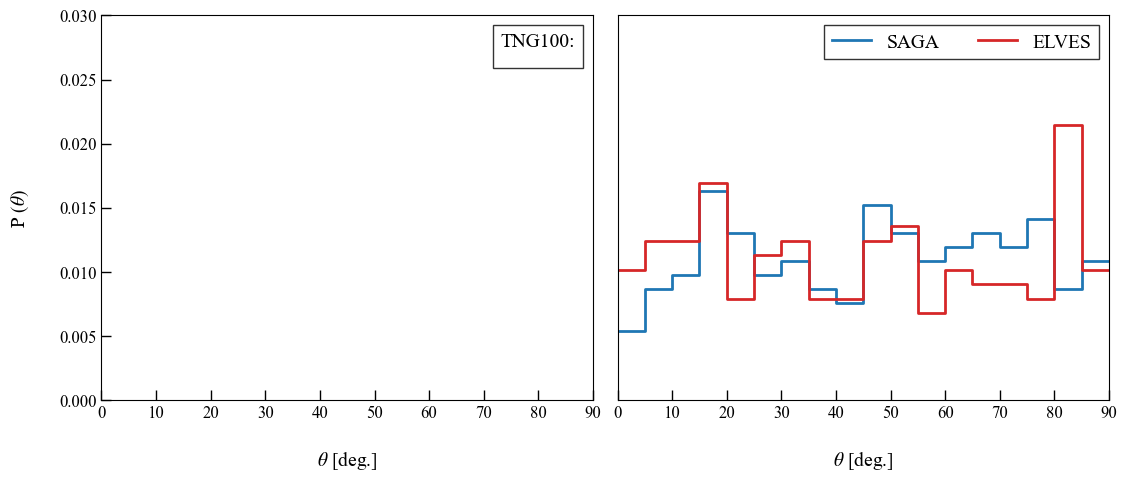

In [58]:
# New high-contrast colors
saga_line = '#1f77b4'
saga_fill = '#aec7e8'
elves_line = '#d62728'
elves_fill = '#ff9896'

fig, (ax_hist,ax_hist2) = plt.subplots(1, 2, figsize=(13, 5))

# ===============================
# TOP PANEL — STEP HISTOGRAM
# ===============================

# NOTE: the left panel (ax_hist) is reserved for an optional TNG100 comparison;
# it is intentionally left without plotted data here since TNG100 histogram
# lines are not computed in this notebook (see the INCLUDE_TNG note in Setup).


# SDSS, TNG, SMDPL (from Michael)

# load data





#ax_hist.step(edges, np.r_[smdpl_hist, smdpl_hist[-1]], where="post", label="SMDPL", lw = 2, color = 'black', ls = ':')


#ax.axhline(5/90,color='black',ls='--',lw=2,label='Uniform Dist.')

saga_90 = map_to_0_90(saga_PA)
elves_90 = map_to_0_90(elves_PA)
bins = np.linspace(0, 90, 19)

counts_saga, _ = np.histogram(saga_90, bins=bins, density=True)
ax_hist2.step(bins, np.append(counts_saga, counts_saga[-1]),where='post', color=saga_line, linewidth=2, label='SAGA')

counts_elves, _ = np.histogram(elves_90, bins=bins, density=True)
ax_hist2.step(bins, np.append(counts_elves, counts_elves[-1]),where='post', color=elves_line, linewidth=2, label='ELVES')
#ax_hist.scatter(bins, np.append(counts_elves, counts_elves[-1]), color=elves_line, label='ELVES')

#angle_grid_deg = np.linspace(0, 90, 300)
#uniform_density = 1/90
#ax_hist.axhspan(uniform_density, uniform_density, color='black')

max_density = max(counts_saga.max(), counts_elves.max())

ax_hist.set_ylabel(r'P ($\theta$)', fontsize=14, labelpad=20)
ax_hist.set_xlabel(r'$\theta$ [deg.]', fontsize=14, labelpad=20)
ax_hist2.set_xlabel(r'$\theta$ [deg.]', fontsize=14, labelpad=20)

ax_hist.set_xlim(0, 90)
ax_hist2.set_xlim(0, 90)

ax_hist.set_ylim(0, 0.030)
ax_hist2.set_ylim(0, 0.030)

ax_hist.legend(fontsize=14,loc='upper right', fancybox=False, edgecolor='black',ncol=1,title='TNG100:',title_fontsize=14)
ax_hist2.legend(fontsize=14,loc='upper right', fancybox=False, edgecolor='black',ncol=2)

ax_hist.tick_params(axis="both", which="major", direction="in", labelsize=12, length=7, width=1)
ax_hist.tick_params(axis="both", which="minor", direction="in", labelsize=12, length=2, width=1)

ax_hist2.tick_params(axis="both", which="major", direction="in", labelsize=12, length=7, width=1)
ax_hist2.tick_params(axis="both", which="minor", direction="in", labelsize=12, length=2, width=1)

ax_hist2.set_yticks([])

plt.subplots_adjust(wspace=0.05)
plt.show()

In [59]:
# Shared angle bin-centers (0-90 deg) used by the SAGA, ELVES, and (optional) TNG100 fits below
angle_array = np.loadtxt('angle_array.txt')


### Mean Angle 

In [60]:
# import TNG100 data (three satellite stellar-mass thresholds: 1e6, 1e7, 1e8 Msun)
if INCLUDE_TNG:
    # import TNG100 data

    df_tng100_1e8 = pd.read_csv("satellite_1e8/centrals_satellites_tng100_mstar_1e8.csv")
    df_tng100_host_mh_1e8 = pd.read_csv("satellite_1e8/centrals_satellites_tng100_host_mh_1e8.csv")
    df_tng100_alpha_1e8 = pd.read_csv("satellite_1e8/centrals_satellites_tng100_alpha_1e8.csv")

    index_1e8 = (df_tng100_host_mh_1e8['host_mh'] > 12) & (df_tng100_host_mh_1e8['host_mh'] < 12.5)

    df_tng100_1e7 = pd.read_csv("satellite_1e7/centrals_satellites_tng100_mstar_1e7.csv")
    df_tng100_host_mh_1e7 = pd.read_csv("satellite_1e7/centrals_satellites_tng100_host_mh_1e7.csv")
    df_tng100_alpha_1e7 = pd.read_csv("satellite_1e7/centrals_satellites_tng100_alpha_1e7.csv")

    index_1e7 = (df_tng100_host_mh_1e7['host_mh'] > 12) & (df_tng100_host_mh_1e7['host_mh'] < 12.5)

    df_tng100_1e6 = pd.read_csv("satellite_1e6/centrals_satellites_tng100_mstar_1e6.csv")
    df_tng100_host_mh_1e6 = pd.read_csv("satellite_1e6/centrals_satellites_tng100_host_mh_1e6.csv")
    df_tng100_alpha_1e6 = pd.read_csv("satellite_1e6/centrals_satellites_tng100_alpha_1e6.csv")

    index_1e6 = (df_tng100_host_mh_1e6['host_mh'] > 12) & (df_tng100_host_mh_1e6['host_mh'] < 12.5)
else:
    print('INCLUDE_TNG is False -- skipping TNG100 data import.')


INCLUDE_TNG is False -- skipping TNG100 data import.


In [61]:
if INCLUDE_TNG:
    print(np.mean(df_tng100_alpha_1e8[index_1e8]),np.std(df_tng100_alpha_1e8[index_1e8]))
    print(np.mean(df_tng100_alpha_1e7[index_1e7]),np.std(df_tng100_alpha_1e7[index_1e7]))
    print(np.mean(df_tng100_alpha_1e6[index_1e6]),np.std(df_tng100_alpha_1e6[index_1e6]))
else:
    print('INCLUDE_TNG is False -- skipping TNG100 alpha summary stats.')


INCLUDE_TNG is False -- skipping TNG100 alpha summary stats.


### One-Sample KS-Test

INCLUDE_TNG is False -- skipping TNG100 CDF curves.


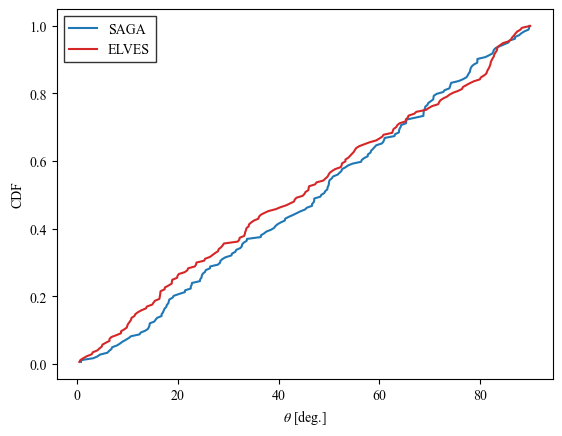

In [62]:
sort_saga = np.argsort(saga_90)
sort_elves = np.argsort(np.array(elves_90_correct))

cdf_saga = np.arange(1, len(saga_90)+1) / len(saga_90)
cdf_elves = np.arange(1, len(elves_90_correct)+1) / len(elves_90_correct)

plt.plot(saga_90[sort_saga], cdf_saga, color=saga_line, label='SAGA')
plt.plot(np.array(elves_90_correct)[sort_elves], cdf_elves, color=elves_line, label='ELVES')

if INCLUDE_TNG:

    angles_1d_1e8 = df_tng100_alpha_1e8.iloc[:,0].to_numpy()
    sort_tng100_1e8 = np.argsort(angles_1d_1e8)
    cdf_tng100_1e8 = np.arange(1, len(angles_1d_1e8)+1) / len(angles_1d_1e8)
    plt.plot(angles_1d_1e8[sort_tng100_1e8], cdf_tng100_1e8, color='black', ls = '-', label='TNG 1e8')

    angles_1d_1e7 = df_tng100_alpha_1e7.iloc[:,0].to_numpy()
    sort_tng100_1e7 = np.argsort(angles_1d_1e7)
    cdf_tng100_1e7 = np.arange(1, len(angles_1d_1e7)+1) / len(angles_1d_1e7)
    plt.plot(angles_1d_1e7[sort_tng100_1e7], cdf_tng100_1e7, color='black', ls = '--', label='TNG 1e7')

    angles_1d_1e6 = df_tng100_alpha_1e6.iloc[:,0].to_numpy()
    sort_tng100_1e6 = np.argsort(angles_1d_1e6)
    cdf_tng100_1e6 = np.arange(1, len(angles_1d_1e6)+1) / len(angles_1d_1e6)
    plt.plot(angles_1d_1e6[sort_tng100_1e6], cdf_tng100_1e6, color='black', ls = ':', label='TNG 1e6')
else:
    print('INCLUDE_TNG is False -- skipping TNG100 CDF curves.')

# Plot

plt.xlabel(r'$\theta$ [deg.]')
plt.ylabel('CDF')
plt.legend(fancybox=False,edgecolor='k',ncol=1)
plt.show()

In [63]:
# implement one-sample K-S test
# see https://www.astroml.org/astroML-notebooks/chapter4/astroml_chapter4_Comparison_of_distributions.html

import scipy.stats as stats

# example from website
#np.random.seed(0)
#vals = np.random.normal(loc=0, scale=1, size= 1000)
#print(f'Normal: {stats.kstest(vals, "norm")}')
#print(f'Uniform: {stats.kstest(vals, "uniform")}')

print(f'Uniform: {stats.kstest(saga_90[sort_saga], "uniform",args=(0, 90))}')
print(f'Uniform: {stats.kstest(np.array(elves_90_correct)[sort_elves], "uniform",args=(0, 90))}')


if INCLUDE_TNG:


    print(f'Uniform: {stats.kstest(angles_1d_1e8[sort_tng100_1e8], "uniform",args=(0, 90))}')
    print(f'Uniform: {stats.kstest(angles_1d_1e7[sort_tng100_1e7], "uniform",args=(0, 90))}')
    print(f'Uniform: {stats.kstest(angles_1d_1e6[sort_tng100_1e6], "uniform",args=(0, 90))}')
else:
    print('INCLUDE_TNG is False -- skipping TNG100 uniformity KS-tests.')


Uniform: KstestResult(statistic=0.05844748725163064, pvalue=0.5363942541253537, statistic_location=14.064621678733715, statistic_sign=-1)
Uniform: KstestResult(statistic=0.052627365231793566, pvalue=0.6907804344863296, statistic_location=79.99070015899702, statistic_sign=-1)
INCLUDE_TNG is False -- skipping TNG100 uniformity KS-tests.


In [64]:
# (scipy.stats already imported in Setup above; re-imported here since this cell was originally standalone)
from scipy import stats

### Two-Sample KS-Test (+ One-Sample KS-Test for Q and SF subsample)

In [65]:
# Flatten the ELVES 0-90 angle list (each entry was a 1-element array) into a plain array
#elves_quenched = elves_quenched.to_numpy()
elves_90_correct = np.array(elves_90_correct)

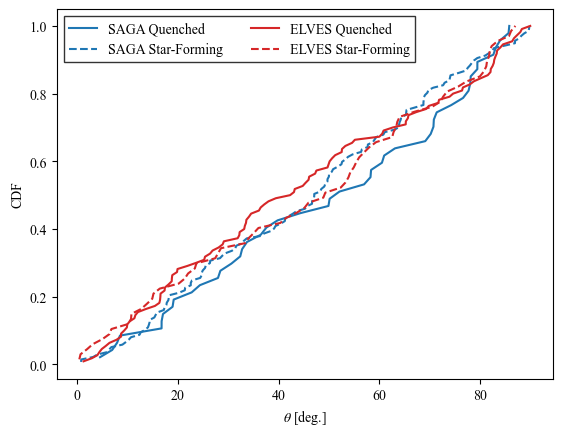

In [66]:
# Split SAGA/ELVES samples into quenched (Q) vs. star-forming (SF) subsets
saga_q = (saga_quenched == 1)
saga_sf = (saga_quenched == 0)
sort_saga_q = np.argsort(saga_90[saga_q])
sort_saga_sf = np.argsort(saga_90[saga_sf])

#sort_elves = np.argsort(np.array(elves_90_correct))

elves_q = (elves_quenched == 1)
elves_sf = (elves_quenched == 0)
sort_elves_q = np.argsort(elves_90_correct[elves_q])
sort_elves_sf = np.argsort(elves_90_correct[elves_sf])

cdf_saga_q = np.arange(1, len(saga_90[saga_q])+1) / len(saga_90[saga_q])
cdf_saga_sf = np.arange(1, len(saga_90[saga_sf])+1) / len(saga_90[saga_sf])

cdf_elves_q = np.arange(1, len(elves_90_correct[elves_q])+1) / len(elves_90_correct[elves_q])
cdf_elves_sf = np.arange(1, len(elves_90_correct[elves_sf])+1) / len(elves_90_correct[elves_sf])

plt.plot(saga_90[saga_q][sort_saga_q], cdf_saga_q, color=saga_line, ls = '-', label='SAGA Quenched')
plt.plot(saga_90[saga_sf][sort_saga_sf], cdf_saga_sf, color=saga_line, ls = '--', label='SAGA Star-Forming')

plt.plot(elves_90_correct[elves_q][sort_elves_q], cdf_elves_q, color=elves_line, ls = '-', label='ELVES Quenched')
plt.plot(elves_90_correct[elves_sf][sort_elves_sf], cdf_elves_sf, color=elves_line, ls = '--', label='ELVES Star-Forming')

# plot isotropic expectation
#theta_ref = np.linspace(0, 90, 200)
#cdf_iso = theta_ref / 90.0
#plt.plot(theta_ref, cdf_iso, color='black', ls='-', lw=2)

plt.xlabel(r'$\theta$ [deg.]')
plt.ylabel('CDF')
plt.legend(fancybox=False,edgecolor='k',ncol=2)
plt.show()

In [67]:
# One-sample KS test: is each Q/SF subsample consistent with a uniform angle distribution?
# two-sample KS test for SAGA/ELVES

print('SAGA:')
print(f'Q against Uniform Dist.: {stats.kstest(saga_90[saga_q][sort_saga_q], "uniform",args=(0, 90))}')
print(f'SF against Uniform Dist.: {stats.kstest(saga_90[saga_sf][sort_saga_sf], "uniform",args=(0, 90))}')
print(' ')
print('ELVES:')
print(f'Q against Uniform Dist.: {stats.kstest(elves_90_correct[elves_q][sort_elves_q], "uniform",args=(0, 90))}')
print(f'SF against Uniform Dist.: {stats.kstest(elves_90_correct[elves_sf][sort_elves_sf], "uniform",args=(0, 90))}')

#print(f'ELVES Q vs. SF: {stats.ks_2samp(elves_90_correct[elves_q][sort_elves_q], elves_90_correct[elves_sf][sort_elves_sf])}')

SAGA:
Q against Uniform Dist.: KstestResult(statistic=0.12995988169075923, pvalue=0.3730709549029734, statistic_location=69.14319786280663, statistic_sign=-1)
SF against Uniform Dist.: KstestResult(statistic=0.0573256950524383, pvalue=0.7367052295973298, statistic_location=12.38558992698222, statistic_sign=-1)
 
ELVES:
Q against Uniform Dist.: KstestResult(statistic=0.061494764014825065, pvalue=0.7763165106411352, statistic_location=34.556380329574836, statistic_sign=1)
SF against Uniform Dist.: KstestResult(statistic=0.0742161155066775, pvalue=0.8275286414006502, statistic_location=52.35109218664576, statistic_sign=-1)


In [68]:
# Two-sample KS test: are the Q and SF angle distributions different from each other?
# two-sample KS test for SAGA/ELVES

print(f'SAGA Q vs. SF: {stats.ks_2samp(saga_90[saga_q][sort_saga_q], saga_90[saga_sf][sort_saga_sf])}')
print(' ')
print(f'ELVES Q vs. SF: {stats.ks_2samp(elves_90_correct[elves_q][sort_elves_q], elves_90_correct[elves_sf][sort_elves_sf])}')

SAGA Q vs. SF: KstestResult(statistic=0.15732256561577884, pvalue=0.31115086712769086, statistic_location=69.08886787710827, statistic_sign=-1)
 
ELVES Q vs. SF: KstestResult(statistic=0.12306648575305291, pvalue=0.5040314649247061, statistic_location=53.27694524733624, statistic_sign=1)


In [69]:
if INCLUDE_TNG:
    # TNG100-1 plot

    # 1e8

    df_tng100_1e8 = pd.read_csv("satellite_1e8/centrals_satellites_tng100_mstar_1e8.csv")
    df_tng100_host_mh_1e8 = pd.read_csv("satellite_1e8/centrals_satellites_tng100_host_mh_1e8.csv")
    df_tng100_alpha_1e8 = pd.read_csv("satellite_1e8/centrals_satellites_tng100_alpha_1e8.csv")
    tng100_sfr_info_1e8 = pd.read_csv("satellite_1e8/tng100_sfr_info_1e8.csv")

    index = (df_tng100_host_mh_1e8['host_mh'] > 12) & (df_tng100_host_mh_1e8['host_mh'] < 12.5)
    sfr_interp = np.log10((10**(0.75*tng100_sfr_info_1e8['mstar'][index]-7.5))/10)
    index_sf = (10**sfr_interp <= tng100_sfr_info_1e8['sfr'][index])
    index_q = (10**sfr_interp > tng100_sfr_info_1e8['sfr'][index])
    q_sf_array = np.ones(len(tng100_sfr_info_1e8['host_mh'][index]))
    q_sf_array[index_sf] = 0.

    angles_all = df_tng100_alpha_1e8.iloc[:, 0]
    angles_q  = angles_all[index][index_q]
    angles_sf = angles_all[index][index_sf]
    angles_q_sorted  = np.sort(angles_q)
    angles_sf_sorted = np.sort(angles_sf)
    cdf_q  = np.arange(1, len(angles_q_sorted)  + 1) / len(angles_q_sorted)
    cdf_sf = np.arange(1, len(angles_sf_sorted) + 1) / len(angles_sf_sorted)
    plt.plot(angles_q_sorted,  cdf_q,  color='black', ls='-',  label='TNG 1e8 Q')
    plt.plot(angles_sf_sorted, cdf_sf, color='black', ls='--', label='TNG 1e8 SF')

    # two-sample KS test
    print(f'TNG100-1, Msat > 1e8: {stats.ks_2samp(angles_q_sorted, angles_sf_sorted)}')
    # one-sample KS test
    print(f'Q against Uniform Dist.: {stats.kstest(angles_q_sorted, "uniform",args=(0, 90))}')
    print(f'SF against Uniform Dist.: {stats.kstest(angles_sf_sorted, "uniform",args=(0, 90))}')
    print(' ')

    # 1e7

    df_tng100_1e7 = pd.read_csv("satellite_1e7/centrals_satellites_tng100_mstar_1e7.csv")
    df_tng100_host_mh_1e7 = pd.read_csv("satellite_1e7/centrals_satellites_tng100_host_mh_1e7.csv")
    df_tng100_alpha_1e7 = pd.read_csv("satellite_1e7/centrals_satellites_tng100_alpha_1e7.csv")
    tng100_sfr_info_1e7 = pd.read_csv("satellite_1e7/tng100_sfr_info_1e7.csv")

    index = (df_tng100_host_mh_1e7['host_mh'] > 12) & (df_tng100_host_mh_1e7['host_mh'] < 12.5)
    sfr_interp = np.log10((10**(0.75*tng100_sfr_info_1e7['mstar'][index]-7.5))/10)
    index_sf = (10**sfr_interp <= tng100_sfr_info_1e7['sfr'][index])
    index_q = (10**sfr_interp > tng100_sfr_info_1e7['sfr'][index])
    q_sf_array = np.ones(len(tng100_sfr_info_1e7['host_mh'][index]))
    q_sf_array[index_sf] = 0.

    angles_all = df_tng100_alpha_1e7.iloc[:, 0]
    angles_q  = angles_all[index][index_q]
    angles_sf = angles_all[index][index_sf]
    angles_q_sorted  = np.sort(angles_q)
    angles_sf_sorted = np.sort(angles_sf)
    cdf_q  = np.arange(1, len(angles_q_sorted)  + 1) / len(angles_q_sorted)
    cdf_sf = np.arange(1, len(angles_sf_sorted) + 1) / len(angles_sf_sorted)
    plt.plot(angles_q_sorted,  cdf_q,  color='black', ls='-',  label='TNG 1e7 Q')
    plt.plot(angles_sf_sorted, cdf_sf, color='black', ls='--', label='TNG 1e7 SF')

    # two-sample KS test
    print(f'TNG100-1, Msat > 1e7: {stats.ks_2samp(angles_q_sorted, angles_sf_sorted)}')
    # one-sample KS test
    print(f'Q against Uniform Dist.: {stats.kstest(angles_q_sorted, "uniform",args=(0, 90))}')
    print(f'SF against Uniform Dist.: {stats.kstest(angles_sf_sorted, "uniform",args=(0, 90))}')
    print(' ')

    # 1e6

    df_tng100_1e6 = pd.read_csv("satellite_1e6/centrals_satellites_tng100_mstar_1e6.csv")
    df_tng100_host_mh_1e6 = pd.read_csv("satellite_1e6/centrals_satellites_tng100_host_mh_1e6.csv")
    df_tng100_alpha_1e6 = pd.read_csv("satellite_1e6/centrals_satellites_tng100_alpha_1e6.csv")
    tng100_sfr_info_1e6 = pd.read_csv("satellite_1e6/tng100_sfr_info_1e6.csv")

    index = (df_tng100_host_mh_1e6['host_mh'] > 12) & (df_tng100_host_mh_1e6['host_mh'] < 12.5)
    sfr_interp = np.log10((10**(0.75*tng100_sfr_info_1e6['mstar'][index]-7.5))/10)
    index_sf = (10**sfr_interp <= tng100_sfr_info_1e6['sfr'][index])
    index_q = (10**sfr_interp > tng100_sfr_info_1e6['sfr'][index])
    q_sf_array = np.ones(len(tng100_sfr_info_1e6['host_mh'][index]))
    q_sf_array[index_sf] = 0.

    angles_all = df_tng100_alpha_1e6.iloc[:, 0]
    angles_q  = angles_all[index][index_q]
    angles_sf = angles_all[index][index_sf]
    angles_q_sorted  = np.sort(angles_q)
    angles_sf_sorted = np.sort(angles_sf)
    cdf_q  = np.arange(1, len(angles_q_sorted)  + 1) / len(angles_q_sorted)
    cdf_sf = np.arange(1, len(angles_sf_sorted) + 1) / len(angles_sf_sorted)
    plt.plot(angles_q_sorted,  cdf_q,  color='black', ls='-',  label='TNG 1e6 Q')
    plt.plot(angles_sf_sorted, cdf_sf, color='black', ls='--', label='TNG 1e6 SF')

    # two-sample KS test
    print(f'TNG100-1, Msat > 1e6: {stats.ks_2samp(angles_q_sorted, angles_sf_sorted)}')
    # one-sample KS test
    print(f'Q against Uniform Dist.: {stats.kstest(angles_q_sorted, "uniform",args=(0, 90))}')
    print(f'SF against Uniform Dist.: {stats.kstest(angles_sf_sorted, "uniform",args=(0, 90))}')
    print(' ')

    plt.xlabel(r'$\theta$ [deg.]')
    plt.ylabel('CDF')
    plt.legend(fancybox=False,edgecolor='k',ncol=3)
    plt.show()
else:
    print('INCLUDE_TNG is False -- skipping TNG100-1 Q/SF CDF plot and KS-tests.')


INCLUDE_TNG is False -- skipping TNG100-1 Q/SF CDF plot and KS-tests.


## MCMC fit: 

Fit a sinusoidal model $f_q(\theta) = a + b\cos(2\theta)$ to the binned quenched fraction for SAGA and ELVES (and, optionally, TNG100 -- see `INCLUDE_TNG`; the TNG100 fit itself is performed in the companion notebook `tng_bootstrap_fit.ipynb`).

In [70]:
# NOTE: this helper was written for bootstrapping the TNG100 (simulation) quenched
# fraction directly from a dataframe with 'alpha'/Q-SF columns. It is not currently
# called anywhere in this notebook (SAGA/ELVES use `bootstrap_90_observational_binned`
# below instead) -- kept for reference / potential reuse with TNG100 data.
def boostrap_90(data,sf_index,q_index,N):
    
    bins = 18 # same as boostrap function
    dphi = 90/bins/2
    n_bootstrap = N  # number of bootstrap resamples

    # arrays to hold bootstrapped quenched fractions
    boot_fq = np.zeros((n_bootstrap, bins))

    # loop over bootstrap resamples
    for i in range(n_bootstrap):

        sf_sample = data.loc[sf_index].sample(frac=1, replace=True)
        q_sample  = data.loc[q_index].sample(frac=1, replace=True)
        
        g_N_sf, _ = np.histogram(sf_sample['alpha'],density=False, range=[0,90], bins=bins)
        g_N_q, _  = np.histogram(q_sample['alpha'],density=False, range=[0,90], bins=bins)

        with np.errstate(divide="ignore", invalid="ignore"):
            fq = g_N_q / (g_N_q + g_N_sf)
        fq[np.isnan(fq)] = 0.0  # handle empty bins
        
        boot_fq[i] = fq
    
    fq_mean = np.nanmean(boot_fq, axis=0)
    fq_std = np.nanstd(boot_fq, axis=0)

    return fq_mean, fq_std


In [71]:
# Log-likelihood / prior / posterior for the sinusoidal quenched-fraction model,
# shared by the SAGA, ELVES (and optional TNG100) MCMC fits below.
def calculate_log_likelihood(theta, bin_centers, f_q, sigma_i):

    a, b, f = theta

    # Compute total variance
    s_i = sigma_i**2 + (np.exp(f))**2

    # Model prediction
    f_model = a + b * np.cos(2 * np.radians(bin_centers))

    # Residuals and log-likelihood
    residuals = (f_q - f_model)**2 / s_i
    log_likelihood = -0.5 * np.sum(residuals + np.log(2 * np.pi * s_i))
    
    return log_likelihood

def log_prior(theta):
    a, b, f = theta
    if 0 < a < 1 and -1 < b < 1 and -10 < f < 2:
        return 0.0
    return -np.inf

def calculate_log_probability(theta, bin_centers, f_q, sigma_i):
    
    log_prior_val = log_prior(theta)
    if not np.isfinite(log_prior_val):
        return -np.inf
    log_likelihood = calculate_log_likelihood(theta, bin_centers, f_q, sigma_i)
    return log_prior_val + log_likelihood

In [72]:
# repeat for ELVES and SAGA surveys 
# NOTE: `bootstrap_90_observational_binned` is defined twice below (a per-bin
# bootstrap, then an all-sample bootstrap); the second definition is the one
# actually used at runtime, since it overwrites the first.

def bootstrap_90_observational_binned(x, y, N, bins=18, angle_range=(0, 90)):

    x = np.asarray(x)
    y = np.asarray(y, dtype=float)

    bin_edges = np.linspace(angle_range[0], angle_range[1], bins + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    boot_fq = np.full((N, bins), np.nan)

    # loop over bins
    for j in range(bins):
        in_bin = (x >= bin_edges[j]) & (x < bin_edges[j + 1])
        y_bin = y[in_bin]
        n_bin = len(y_bin)

        if n_bin < 2:
            continue  # leave NaN

        # bootstrap galaxies *within this bin*
        for i in range(N):
            idx = np.random.choice(n_bin, size=n_bin, replace=True)
            boot_fq[i, j] = np.mean(y_bin[idx])

    fq_mean = np.nanmean(boot_fq, axis=0)
    fq_std  = np.nanstd(boot_fq, axis=0)

    return bin_centers, fq_mean, fq_std

def bootstrap_90_observational_binned(x, y, N=10000, bins=18, angle_range=(0, 90)):
    """
    Parameters
    ----------
    x : array-like
        Galaxy angles (0-90 deg)
    y : array-like
        Quantity to average per galaxy (e.g., 1 for quenched, 0 for SF)
    N : int
        Number of bootstrap resamples
    bins : int
        Number of bins in angle
    angle_range : tuple
        Min and max of angle (default: 0-90 deg)
    
    Returns
    -------
    bin_centers : array
        Centers of bins
    fq_mean : array
        Mean fraction per bin over all bootstraps
    fq_std : array
        1-sigma uncertainty per bin from bootstrap
    """

    x = np.asarray(x)
    y = np.asarray(y, dtype=float)

    bin_edges = np.linspace(angle_range[0], angle_range[1], bins + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    boot_fq = np.full((N, bins), np.nan)

    n_gal = len(x)

    for i in range(N):
        # bootstrap galaxies *across the full sample*
        idx = np.random.choice(n_gal, size=n_gal, replace=True)
        x_boot = x[idx]
        y_boot = y[idx]

        # histogram per bin
        for j in range(bins):
            in_bin = (x_boot >= bin_edges[j]) & (x_boot < bin_edges[j + 1])
            y_bin = y_boot[in_bin]
            if len(y_bin) > 0:
                boot_fq[i, j] = np.mean(y_bin)
            else:
                boot_fq[i, j] = np.nan  # empty bin

    fq_mean = np.nanmean(boot_fq, axis=0)
    fq_std = np.nanstd(boot_fq, axis=0)

    return bin_centers, fq_mean, fq_std

    
x = saga_90.copy()
y = saga_quenched.copy()

bin_centers, fq_mean_saga, fq_std_saga = bootstrap_90_observational_binned(x, y, N=10000)

elves_90_correct = []
for i in range(len(elves_90)):
    elves_90_correct.append(elves_90[i][0])
x = np.array(elves_90_correct)
y = np.array(elves_quenched)

bin_centers, fq_mean_elves, fq_std_elves = bootstrap_90_observational_binned(x, y, N=10000)

In [73]:
# re-fit SAGA and ELVES data with updated boostrapping 
# (variable names below are local temporaries reused for both the SAGA and ELVES
# fits; despite an earlier 'tng100' name in a previous draft, this fit uses no TNG data)
# SAGA

# MCMC Configuration

n_walkers_full = 20
n_dim_full = 3 
initial_guess_full = [0.7, 0.025, -3]
pos_full = np.array(initial_guess_full) + np.random.randn(n_walkers_full, n_dim_full) * 1e-2

# Setting up the sampler
sampler_full = emcee.EnsembleSampler(n_walkers_full, n_dim_full, calculate_log_probability,args=(angle_array, fq_mean_saga, fq_std_saga))

# Run MCMC
n_steps = 10_000
sampler_full.run_mcmc(pos_full, n_steps, progress=True)

# Post-Processing
samples_full = sampler_full.get_chain(discard=1000, flat=True)
log_prob_full = sampler_full.get_log_prob(discard=1000, flat=True)

mean_params = np.mean(samples_full, axis=0)
std_params = np.std(samples_full, axis=0)
a_saga, b_saga, f_saga = mean_params
a_saga_std, b_saga_std, f_saga_std = std_params

# ELVES 

# MCMC Configuration

n_walkers_full = 20
n_dim_full = 3 
initial_guess_full = [0.7, 0.025, -3]
pos_full = np.array(initial_guess_full) + np.random.randn(n_walkers_full, n_dim_full) * 1e-2

# Setting up the sampler
sampler_full = emcee.EnsembleSampler(n_walkers_full, n_dim_full, calculate_log_probability,args=(angle_array, fq_mean_elves, fq_std_elves))

# Run MCMC
n_steps = 10_000
sampler_full.run_mcmc(pos_full, n_steps, progress=True)

# Post-Processing
samples_full = sampler_full.get_chain(discard=1000, flat=True)
log_prob_full = sampler_full.get_log_prob(discard=1000, flat=True)

mean_params = np.mean(samples_full, axis=0)
std_params = np.std(samples_full, axis=0)
a_elves, b_elves, f_elves = mean_params
a_elves_std, b_elves_std, f_elves_std = std_params

  0%|          | 0/10000 [00:00<?, ?it/s]

  1%|          | 107/10000 [00:00<00:09, 1069.19it/s]

  2%|▏         | 216/10000 [00:00<00:09, 1080.42it/s]

  3%|▎         | 325/10000 [00:00<00:11, 822.05it/s] 

  4%|▍         | 433/10000 [00:00<00:10, 906.11it/s]

...

 96%|█████████▌| 9566/10000 [00:08<00:00, 1170.80it/s]

 97%|█████████▋| 9684/10000 [00:08<00:00, 1165.81it/s]

 98%|█████████▊| 9801/10000 [00:08<00:00, 1160.43it/s]

 99%|█████████▉| 9920/10000 [00:08<00:00, 1168.64it/s]

100%|██████████| 10000/10000 [00:08<00:00, 1145.86it/s]

INCLUDE_TNG is False -- skipping TNG100 sinusoidal-fit panel.


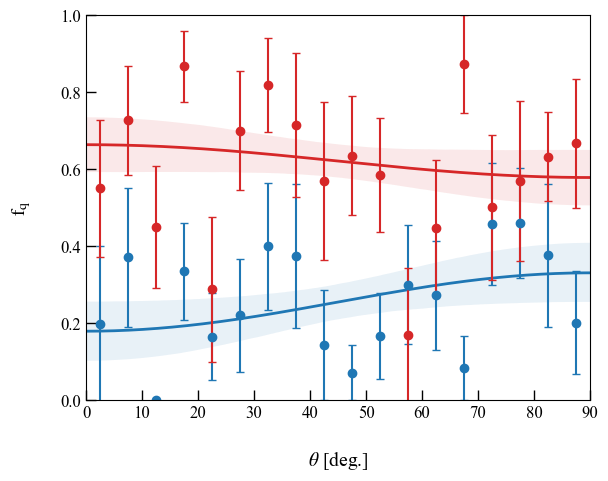

In [74]:
# New high-contrast colors
saga_line = '#1f77b4'
saga_fill = '#aec7e8'
elves_line = '#d62728'
elves_fill = '#ff9896'

if INCLUDE_TNG:
    fig, (ax_hist, ax_hist2) = plt.subplots(1, 2, figsize=(13, 5))
else:
    fig, ax_hist2 = plt.subplots(1, 1, figsize=(6.5, 5))

if INCLUDE_TNG:

    # SDSS, TNG, SMDPL (from Michael)

    #sdss_fq = np.loadtxt('../../sdss/figure1/sdss_fq.txt')
    #tng100_fq = np.loadtxt('../../sdss/figure1/tng100_fq.txt')
    #smdpl_fq = np.loadtxt('../../sdss/figure1/smdpl_fq.txt')

    sdss_hist = sdss_number_count / np.sum(sdss_number_count) / 5
    tng_hist  = tng100_number_count / np.sum(tng100_number_count) / 5
    tng_hist_1e7  = tng100_number_count_1e7 / np.sum(tng100_number_count_1e7) / 5
    tng_hist_1e6  = tng100_number_count_1e6 / np.sum(tng100_number_count_1e6) / 5
    smdpl_hist = smdpl_number_count / np.sum(smdpl_number_count) / 5
    bin_width = np.diff(angle_array).mean()
    edges = np.concatenate([angle_array - bin_width/2,[angle_array[-1] + bin_width/2]])

    ax_hist.errorbar(angle_array, fq_mean_1e8, yerr=fq_std_1e8,fmt='o', color='black', mfc='black', mec='black', mew=1,capsize=3)
    ax_hist.errorbar(angle_array, fq_mean_1e7, yerr=fq_std_1e7,fmt='o', color='black', mfc='black', mec='black', mew=1,capsize=3)
    ax_hist.errorbar(angle_array, fq_mean_1e6, yerr=fq_std_1e6,fmt='o', color='black', mfc='black', mec='black', mew=1,capsize=3)

    x = np.linspace(0,np.pi/2,1000)
    ax_hist.plot((x*u.rad).to('degree'),a_1e6 + b_1e6 * np.cos(2 * x),color='black', lw=2,ls=':')
    ax_hist.plot((x*u.rad).to('degree'),a_1e7 + b_1e7 * np.cos(2 * x),color='black', lw=2,ls='--')
    ax_hist.plot((x*u.rad).to('degree'),a_1e8 + b_1e8 * np.cos(2 * x),color='black', lw=2,ls='-')

    n_mc = 10000
    a_samp = np.random.normal(a_1e6, a_1e6_std, n_mc)
    b_samp = np.random.normal(b_1e6, b_1e6_std, n_mc)
    cos2x = np.cos(2 * x)
    y_mc = a_samp[:, None] + b_samp[:, None] * cos2x[None, :]
    y_med   = np.percentile(y_mc, 50, axis=0)
    y_low   = np.percentile(y_mc, 16, axis=0)
    y_high  = np.percentile(y_mc, 84, axis=0)
    theta_deg = (x * u.rad).to('degree').value
    ax_hist.fill_between(theta_deg,y_low,y_high,color='k',alpha=0.1,edgecolor=None)

    n_mc = 10000
    a_samp = np.random.normal(a_1e7, a_1e7_std, n_mc)
    b_samp = np.random.normal(b_1e7, b_1e7_std, n_mc)
    cos2x = np.cos(2 * x)
    y_mc = a_samp[:, None] + b_samp[:, None] * cos2x[None, :]
    y_med   = np.percentile(y_mc, 50, axis=0)
    y_low   = np.percentile(y_mc, 16, axis=0)
    y_high  = np.percentile(y_mc, 84, axis=0)
    theta_deg = (x * u.rad).to('degree').value
    ax_hist.fill_between(theta_deg,y_low,y_high,color='k',alpha=0.1,edgecolor=None)

    n_mc = 10000
    a_samp = np.random.normal(a_1e8, a_1e8_std, n_mc)
    b_samp = np.random.normal(b_1e8, b_1e8_std, n_mc)
    cos2x = np.cos(2 * x)
    y_mc = a_samp[:, None] + b_samp[:, None] * cos2x[None, :]
    y_med   = np.percentile(y_mc, 50, axis=0)
    y_low   = np.percentile(y_mc, 16, axis=0)
    y_high  = np.percentile(y_mc, 84, axis=0)
    theta_deg = (x * u.rad).to('degree').value
    ax_hist.fill_between(theta_deg,y_low,y_high,color='k',alpha=0.1,edgecolor=None)
else:
    print('INCLUDE_TNG is False -- skipping TNG100 sinusoidal-fit panel.')

# SAGA 

total_N_saga = len(saga_quenched)
quench_f_saga = np.sum(saga_quenched) / total_N_saga
a_saga, b_central_saga, b_err_saga = np.mean(saga_quenched), 0.03, 0.07

theta_deg_saga = np.linspace(0, 360, 1000)
signal_lower_saga = a_saga + b_central_saga * np.cos(2 * np.radians(theta_deg_saga)) - b_err_saga
signal_upper_saga = a_saga + b_central_saga * np.cos(2 * np.radians(theta_deg_saga)) + b_err_saga

theta_mapped_saga = map_to_0_90(theta_deg_saga)
sort_idx_saga = np.argsort(theta_mapped_saga)

ax_hist2.errorbar(angle_array, fq_mean_saga, yerr=fq_std_saga,fmt='o', color=saga_line, mfc=saga_line, mec=saga_line, mew=1,capsize=3,label="SAGA")
x = np.linspace(0,np.pi/2,1000)
ax_hist2.plot((x*u.rad).to('degree'),a_saga + b_saga * np.cos(2 * x),color=saga_line, lw=2)

n_mc = 10000
a_samp = np.random.normal(a_saga, a_saga_std, n_mc)
b_samp = np.random.normal(b_saga, b_saga_std, n_mc)
cos2x = np.cos(2 * x)
y_mc = a_samp[:, None] + b_samp[:, None] * cos2x[None, :]
y_med   = np.percentile(y_mc, 50, axis=0)
y_low   = np.percentile(y_mc, 16, axis=0)
y_high  = np.percentile(y_mc, 84, axis=0)
theta_deg = (x * u.rad).to('degree').value
ax_hist2.fill_between(theta_deg,y_low,y_high,color=saga_line,alpha=0.1,edgecolor=None)

# ELVES

total_N_elves = len(elves_quenched)
quench_f_elves = np.sum(elves_quenched) / total_N_elves
a_elves, b_central_elves, b_err_elves = elves_mean, 0.09, 0.04

theta_deg_elves = np.linspace(0, 360, 1000)
signal_lower_elves = a_elves + b_central_elves * np.cos(2 * np.radians(theta_deg_elves)) - b_err_elves
signal_upper_elves = a_elves + b_central_elves * np.cos(2 * np.radians(theta_deg_elves)) + b_err_elves

theta_mapped_elves = map_to_0_90(theta_deg_elves)
sort_idx_elves = np.argsort(theta_mapped_elves)

ax_hist2.errorbar(angle_array, fq_mean_elves, yerr=fq_std_elves,fmt='o', color=elves_line, mfc=elves_line, mec=elves_line, mew=1,capsize=3,label="ELVES")  # FIX: was mislabeled "SAGA" in the original
x = np.linspace(0,np.pi/2,1000)
ax_hist2.plot((x*u.rad).to('degree'),a_elves + b_elves * np.cos(2 * x),color=elves_line, lw=2)

n_mc = 10000
a_samp = np.random.normal(a_elves, a_elves_std, n_mc)
b_samp = np.random.normal(b_elves, b_elves_std, n_mc)
cos2x = np.cos(2 * x)
y_mc = a_samp[:, None] + b_samp[:, None] * cos2x[None, :]
y_med   = np.percentile(y_mc, 50, axis=0)
y_low   = np.percentile(y_mc, 16, axis=0)
y_high  = np.percentile(y_mc, 84, axis=0)
theta_deg = (x * u.rad).to('degree').value
ax_hist2.fill_between(theta_deg,y_low,y_high,color=elves_line,alpha=0.1,edgecolor=None)

if INCLUDE_TNG:
    ax_hist.set_ylabel(r'$\mathrm{f_q}$', fontsize=14, labelpad=20)
    ax_hist.set_xlabel(r'$\theta$ [deg.]', fontsize=14, labelpad=20)
    ax_hist.set_xlim(0, 90)
    ax_hist.set_ylim(0, 1)
    ax_hist.tick_params(axis="both", which="major", direction="in", labelsize=12, length=7, width=1)
    ax_hist.tick_params(axis="both", which="minor", direction="in", labelsize=12, length=2, width=1)
    ax_hist2.set_yticks([])
else:
    ax_hist2.set_ylabel(r'$\mathrm{f_q}$', fontsize=14, labelpad=20)

ax_hist2.set_xlabel(r'$\theta$ [deg.]', fontsize=14, labelpad=20)

ax_hist2.set_xlim(0, 90)

ax_hist2.set_ylim(0, 1)


ax_hist2.tick_params(axis="both", which="major", direction="in", labelsize=12, length=7, width=1)
ax_hist2.tick_params(axis="both", which="minor", direction="in", labelsize=12, length=2, width=1)


plt.subplots_adjust(wspace=0.05)
plt.show()

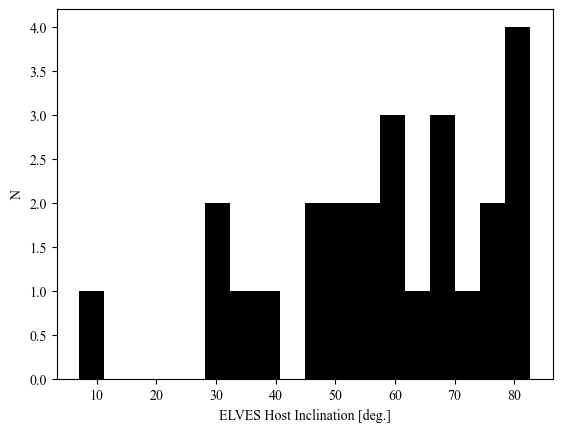

In [75]:
# Merge the refined ELVES host inclinations back into the full (unfiltered) host table
# so we can look up each host's inclination later (e.g. for inclination-based cuts).
# plot ELVES host inclination

elves_inclination_reformat = np.concatenate([c.filled(np.nan) for c in elves_inclination])
elves_PA_reformat = np.concatenate([c.astype(float).filled(np.nan) for c in elves_PA_host])


elves_inclination_reform = np.asarray(elves_inclination_reformat, dtype=float).ravel()
if len(elves_inclination_reform) != len(pa_indices):
    raise ValueError(
        f"Inclination length mismatch: len(elves_inclination_reform)={len(elves_inclination_reform)} "
        f"vs len(pa_indices)={len(pa_indices)}"
    )

hosts = hosts.reset_index(drop=True)
hosts.loc[pa_indices, "Inclination"] = elves_inclination_reform

# Propagate to the full host table for later host->inclination mapping
incl_by_host = pd.Series(hosts["Inclination"].values, index=hosts["Host"]).groupby(level=0).first()
hosts_unfiltered["Inclination"] = hosts_unfiltered["Host"].map(incl_by_host)

plt.hist(elves_inclination_reformat, color="k", bins=18)
plt.xlabel("ELVES Host Inclination [deg.]")
plt.ylabel("N")
plt.show()


In [76]:
# Mask-builder + plotting helpers for the combined SAGA+ELVES comparison below.
# (numpy/matplotlib re-imported here since this cell was originally standalone;
# no TNG data involved -- SAGA/ELVES only.)
import numpy as np
import matplotlib.pyplot as plt

def _ensure_saga_cache():
    pa = saga_PA_raw if "saga_PA_raw" in globals() else saga_PA
    if len(pa) != len(saga_joined):
        raise ValueError("saga_PA_raw must match saga_joined length. Rebuild saga_PA_raw from raw data.")

    if "theta90" not in saga_joined.colnames:
        saga_joined["theta90"] = map_to_0_90(np.asarray(pa))

    if "host_incl_deg" not in saga_joined.colnames:
        saga_joined["host_incl_deg"] = np.degrees(np.arccos(np.asarray(saga_joined["HOST_ba"], dtype=float)))


def _ensure_elves_cache():
    global elves_90, elves_host_incl_deg, elves_host_is_early
    if "elves_90" not in globals():
        elves_90 = np.asarray(map_to_0_90(np.asarray(elves_PA)), dtype=float).ravel()

    host_incl_map = hosts_unfiltered.set_index("Host")["Inclination"]
    elves_host_incl_deg = host_incl_map.reindex(sats["Host"].iloc[kept_indices]).to_numpy(dtype=float)

    early_map = hosts_unfiltered.set_index("Host")["Early_type_host?"].fillna(False).astype(bool)
    elves_host_is_early = early_map.reindex(sats["Host"].iloc[kept_indices]).fillna(False).to_numpy(dtype=bool)

# -----------------------
# Mask builders
# -----------------------
def saga_mask(sample_sel="gold", incl_min=0, r200=True):
    _ensure_saga_cache()
    m = np.ones(len(saga_joined), dtype=bool)

    if r200:
        m &= np.asarray(radius_limit, dtype=bool)

    if sample_sel != "all":
        code = dict(gold=1, silver=2, participation=3).get(sample_sel, sample_sel)
        m &= (np.asarray(saga_joined["sample"]) == code)

    if incl_min and incl_min > 0:
        m &= (np.asarray(saga_joined["host_incl_deg"]) >= float(incl_min))

    return m

def elves_mask(incl_min=0, early_type="all"):
    """
    early_type: 'all' | True | False
    True  -> keep only early-type hosts
    False -> keep only non-early-type hosts
    """
    _ensure_elves_cache()
    m = np.isfinite(elves_host_incl_deg)
    if incl_min and incl_min > 0:
        m &= (elves_host_incl_deg >= float(incl_min))

    if early_type == "all":
        return m
    if early_type is True:
        return m & (elves_host_is_early == True)
    if early_type is False:
        return m & (elves_host_is_early == False)
    raise ValueError("early_type must be 'all', True, or False")

def _combine_saga_mask(samples, incl_min, r200):
    m = np.zeros(len(saga_joined), dtype=bool)
    for samp in samples:
        m |= saga_mask(sample_sel=samp, incl_min=incl_min, r200=r200)
    return m

def run_case_combined(case_name, CASES):
    cfg = CASES[case_name]
    incl_min = cfg.get("incl_min", 0)
    saga_samples = cfg.get("saga_samples", ["gold", "silver", "participation"])
    saga_r200 = cfg.get("saga_r200", True)
    elves_early = cfg.get("elves_early_type", "all")  # 'all', 'none' or True/False
    bins = cfg.get("bins", 18)
    density = cfg.get("density", True)
    Nboot = cfg.get("bootstrap_N", 10000)

    _ensure_saga_cache()
    _ensure_elves_cache()

    # --- SAGA combined mask ---
    m_saga = _combine_saga_mask(saga_samples, incl_min=incl_min, r200=saga_r200)
    saga_theta = np.asarray(saga_joined["theta90"])[m_saga]
    saga_q = np.asarray(saga_joined["quenched"], dtype=int)[m_saga]

    # --- ELVES mask(s) ---
    if elves_early == "all":
        mE = elves_mask(incl_min=incl_min, early_type=True)
        mL = elves_mask(incl_min=incl_min, early_type=False)
    elif elves_early == "none":
        mE = None
        mL = None
        m_all = elves_mask(incl_min=incl_min, early_type="all")
    else:
        mE = None
        mL = None
        m_all = elves_mask(incl_min=incl_min, early_type=elves_early)

    elves_theta = np.asarray(elves_90, dtype=float).ravel()
    elves_q     = np.asarray(elves_quenched, dtype=int).ravel()
    # --- figure with top (angles) and bottom (fq) ---
    fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

    # ===== Top: Angular distribution =====
    edges = np.linspace(0, 90, bins + 1)
    ax_top.hist(saga_theta, bins=edges, histtype="step", linewidth=2, density=density,
                color="black", label=f"SAGA combined (N={len(saga_theta)})")

    if elves_early == "all":
        ax_top.hist(elves_theta[mE], bins=edges, histtype="step", linewidth=2, density=density,
                    color="firebrick", label=f"ELVES early (N={mE.sum()})")
        ax_top.hist(elves_theta[mL], bins=edges, histtype="step", linewidth=2, density=density,
                    color="steelblue", label=f"ELVES late (N={mL.sum()})")
    else:
        ax_top.hist(elves_theta[m_all], bins=edges, histtype="step", linewidth=2, density=density,
                    color="firebrick", label=f"ELVES (N={m_all.sum()})")

    ax_top.set_title(f"Angular distribution (i ≥ {incl_min}°, SAGA r200={saga_r200})")
    ax_top.set_ylabel("PDF" if density else "N")
    ax_top.legend(frameon=False, fontsize=10)
    ax_top.set_xlim(0, 90)

    # ===== Bottom: Quenched fraction =====
    bc_s, fq_s, fe_s = bootstrap_90_observational_binned(saga_theta, saga_q, N=Nboot, bins=bins, angle_range=(0, 90))
    ax_bot.errorbar(bc_s, fq_s, yerr=fe_s, fmt="o", ms=4, capsize=3, color="black",
                    label="SAGA combined:" + f"{','.join(saga_samples)}")

    if elves_early == "all":
        bc_e, fq_e, fe_e = bootstrap_90_observational_binned(elves_theta[mE], elves_q[mE], N=Nboot, bins=bins, angle_range=(0, 90))
        ax_bot.errorbar(bc_e, fq_e, yerr=fe_e, fmt="o", ms=4, capsize=3, color="firebrick",
                        label="ELVES early")

        bc_l, fq_l, fe_l = bootstrap_90_observational_binned(elves_theta[mL], elves_q[mL], N=Nboot, bins=bins, angle_range=(0, 90))
        ax_bot.errorbar(bc_l, fq_l, yerr=fe_l, fmt="o", ms=4, capsize=3, color="steelblue",
                        label="ELVES late")
    else:
        bc_e, fq_e, fe_e = bootstrap_90_observational_binned(elves_theta[m_all], elves_q[m_all], N=Nboot, bins=bins, angle_range=(0, 90))
        ax_bot.errorbar(bc_e, fq_e, yerr=fe_e, fmt="o", ms=4, capsize=3, color="firebrick",
                        label="ELVES")

    ax_bot.set_xlabel(r"Projected Offset Angle $\theta$ [deg] (folded 0–90)")
    ax_bot.set_ylabel(r"$f_q$")
    ax_bot.set_ylim(0, 1)
    ax_bot.legend(frameon=False, fontsize=10)

    fig.tight_layout()
    return fig


/var/folders/52/r93wsrcx1b3cnhc1tg56pl240000gn/T/ipykernel_43944/642229118.py:27: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  early_map = hosts_unfiltered.set_index("Host")["Early_type_host?"].fillna(False).astype(bool)
/var/folders/52/r93wsrcx1b3cnhc1tg56pl240000gn/T/ipykernel_43944/642229118.py:27: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  early_map = hosts_unfiltered.set_index("Host")["Early_type_host?"].fillna(False).astype(bool)


Case 'baseline' completed.


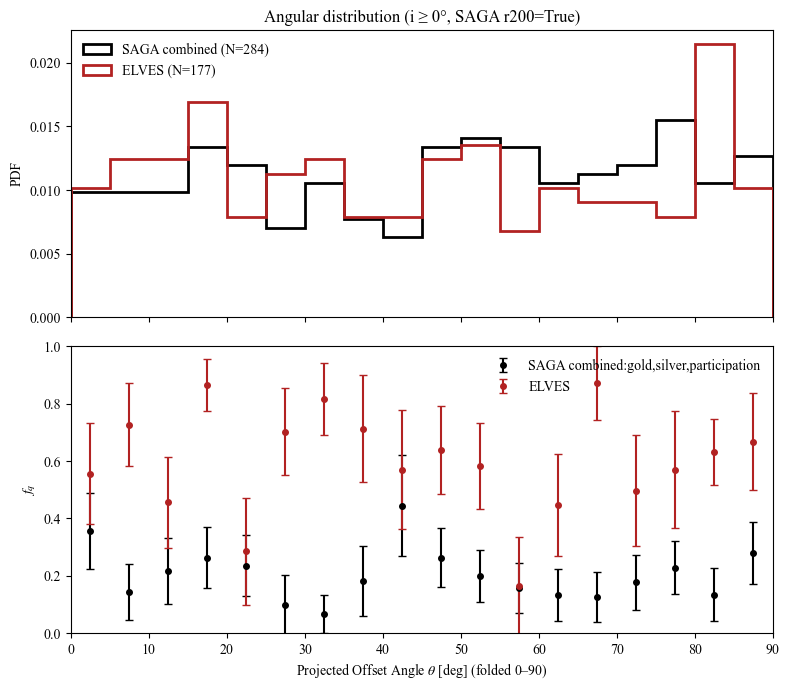

/var/folders/52/r93wsrcx1b3cnhc1tg56pl240000gn/T/ipykernel_43944/642229118.py:27: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  early_map = hosts_unfiltered.set_index("Host")["Early_type_host?"].fillna(False).astype(bool)
/var/folders/52/r93wsrcx1b3cnhc1tg56pl240000gn/T/ipykernel_43944/642229118.py:27: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  early_map = hosts_unfiltered.set_index("Host")["Early_type_host?"].fillna(False).astype(bool)


Case '30_deg_inc_cut' completed.


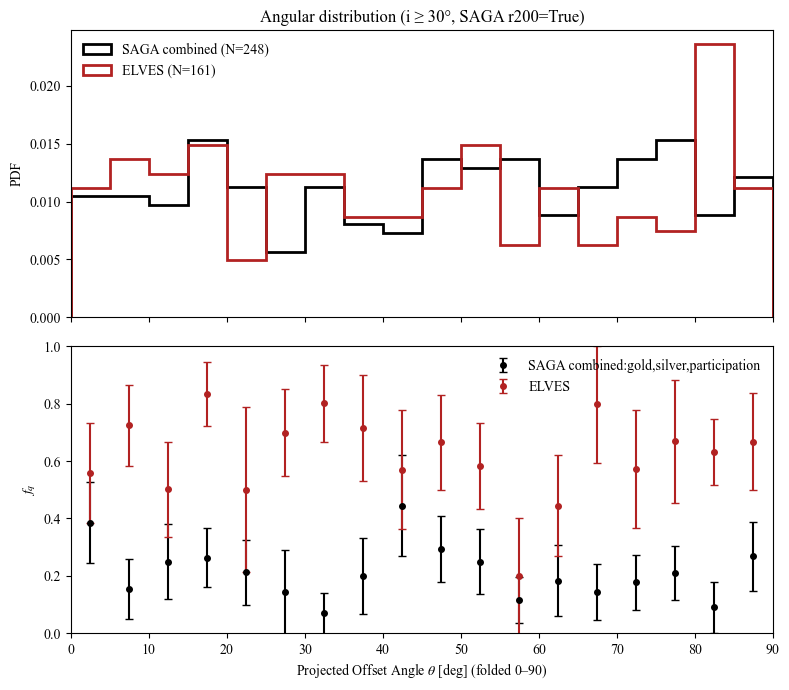

/var/folders/52/r93wsrcx1b3cnhc1tg56pl240000gn/T/ipykernel_43944/642229118.py:27: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  early_map = hosts_unfiltered.set_index("Host")["Early_type_host?"].fillna(False).astype(bool)
/var/folders/52/r93wsrcx1b3cnhc1tg56pl240000gn/T/ipykernel_43944/642229118.py:27: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  early_map = hosts_unfiltered.set_index("Host")["Early_type_host?"].fillna(False).astype(bool)


Case 'gold,silver+30' completed.


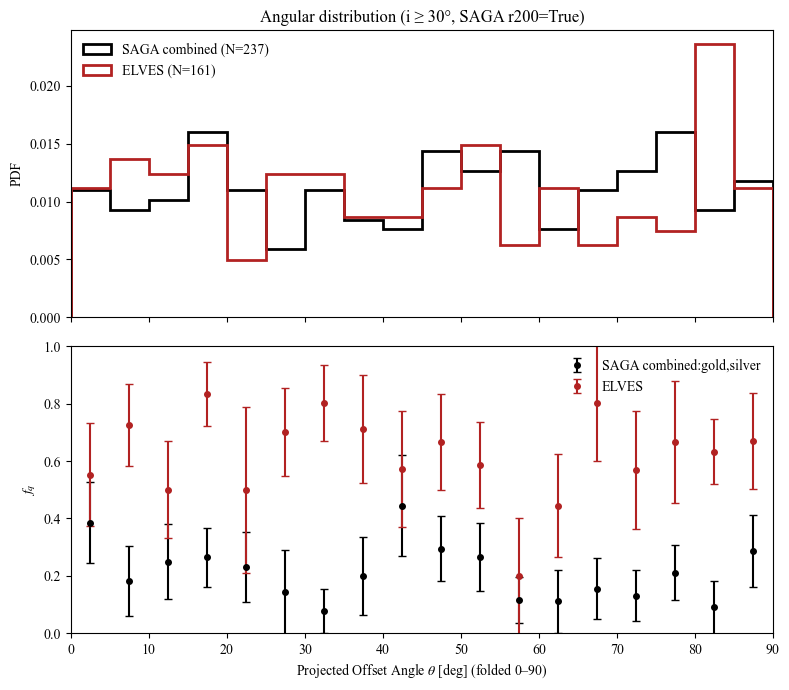

/var/folders/52/r93wsrcx1b3cnhc1tg56pl240000gn/T/ipykernel_43944/642229118.py:27: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  early_map = hosts_unfiltered.set_index("Host")["Early_type_host?"].fillna(False).astype(bool)
/var/folders/52/r93wsrcx1b3cnhc1tg56pl240000gn/T/ipykernel_43944/642229118.py:27: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  early_map = hosts_unfiltered.set_index("Host")["Early_type_host?"].fillna(False).astype(bool)


Case 'gold+30' completed.


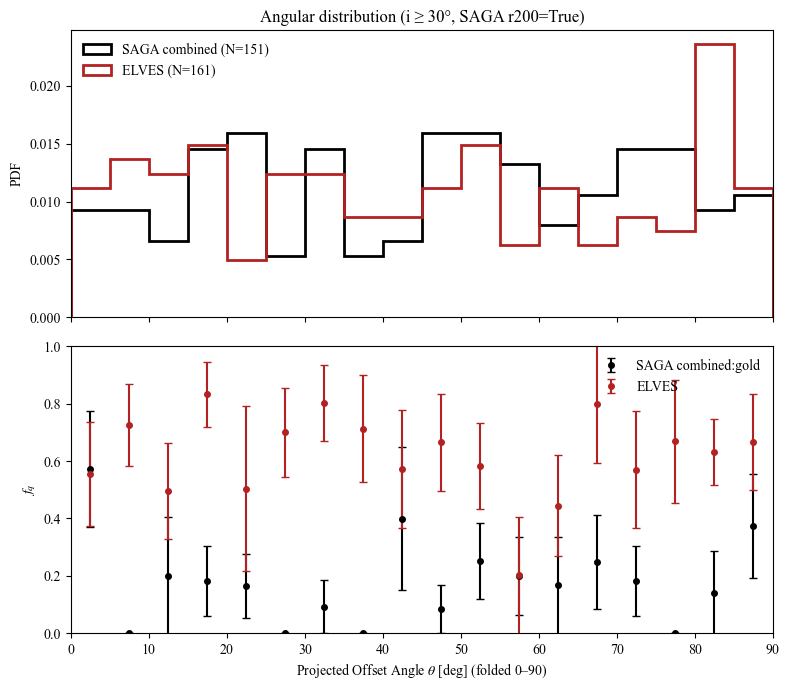

/var/folders/52/r93wsrcx1b3cnhc1tg56pl240000gn/T/ipykernel_43944/642229118.py:27: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  early_map = hosts_unfiltered.set_index("Host")["Early_type_host?"].fillna(False).astype(bool)
/var/folders/52/r93wsrcx1b3cnhc1tg56pl240000gn/T/ipykernel_43944/642229118.py:27: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  early_map = hosts_unfiltered.set_index("Host")["Early_type_host?"].fillna(False).astype(bool)


/var/folders/52/r93wsrcx1b3cnhc1tg56pl240000gn/T/ipykernel_43944/843580454.py:85: RuntimeWarning: Mean of empty slice
  fq_mean = np.nanmean(boot_fq, axis=0)
/Users/nicolasgarcia/opt/anaconda3/envs/py311-main/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Case 'elves_early' completed.


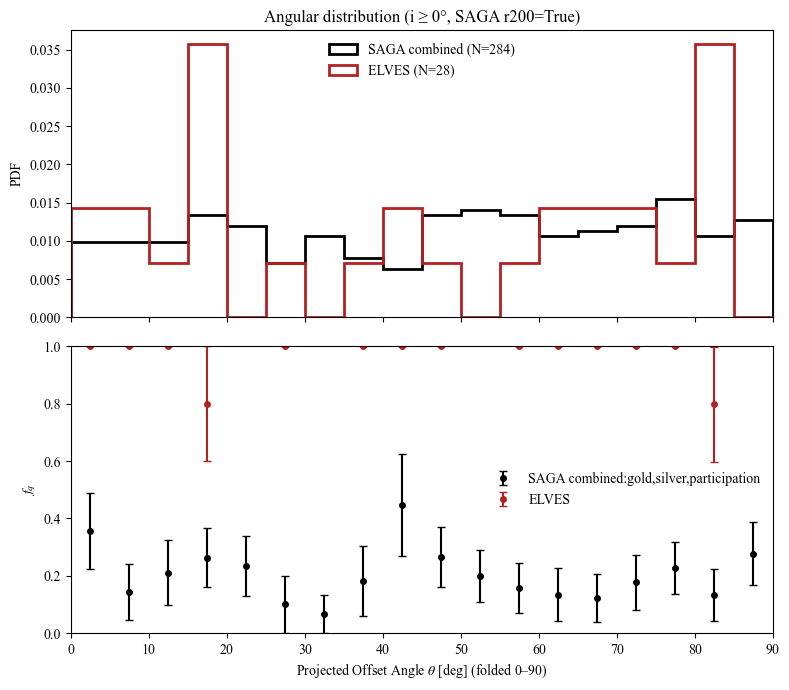

/var/folders/52/r93wsrcx1b3cnhc1tg56pl240000gn/T/ipykernel_43944/642229118.py:27: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  early_map = hosts_unfiltered.set_index("Host")["Early_type_host?"].fillna(False).astype(bool)
/var/folders/52/r93wsrcx1b3cnhc1tg56pl240000gn/T/ipykernel_43944/642229118.py:27: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  early_map = hosts_unfiltered.set_index("Host")["Early_type_host?"].fillna(False).astype(bool)


Case 'elves_late' completed.


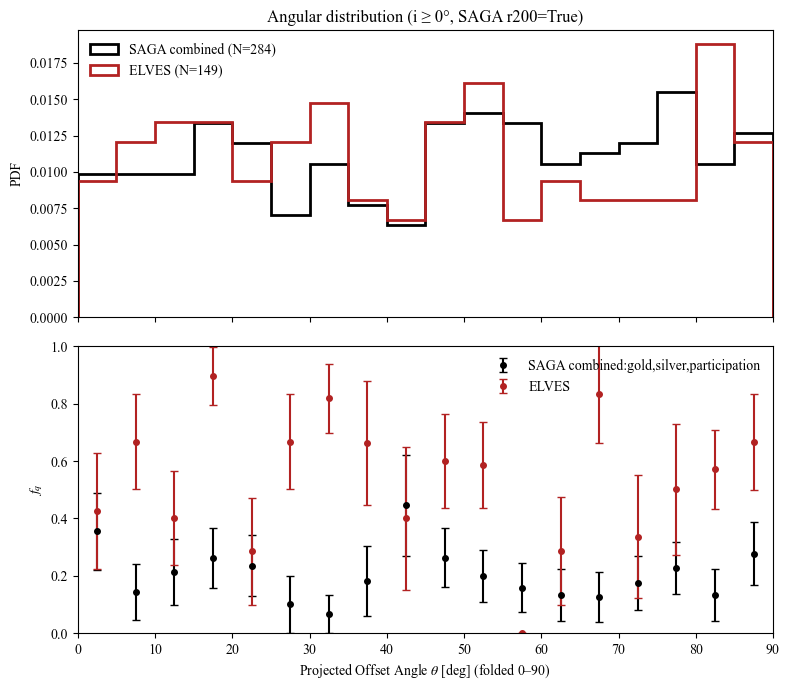

In [77]:
# Define several selection-cut cases and run the combined SAGA+ELVES comparison
# (angle distribution + quenched fraction) for each one.
CASES = {
    "baseline": {
        "incl_min": 0,
        "saga_samples": ["gold", "silver", "participation"],
        "saga_r200": True,
        "elves_early_type": 'none',   # 'all' or True/False
        "bins": 18,
        "bootstrap_N": 10000,
    },
    "30_deg_inc_cut": {
        "incl_min": 30,
        "saga_samples": ["gold", "silver", "participation"],
        "saga_r200": True,
        "elves_early_type": 'none',
        "bins": 18,
        "bootstrap_N": 10000,
    },
    "gold,silver+30": {
        "incl_min": 30,
        "saga_samples": ["gold", "silver"],
        "saga_r200": True,
        "elves_early_type": 'none',
        "bins": 18,
        "bootstrap_N": 10000,
    },
    "gold+30": {
        "incl_min": 30,
        "saga_samples": ["gold"],
        "saga_r200": True,
        "elves_early_type": 'none',
        "bins": 18,
        "bootstrap_N": 10000,

},
    "elves_early": {
        "incl_min": 0,
        "saga_samples": ["gold", "silver", "participation"],
        "saga_r200": True,
        "elves_early_type": True,  # 'all' or True/False
        "bins": 18,
        "bootstrap_N": 10000,
    },
    "elves_late": {
        "incl_min": 0,
        "saga_samples": ["gold", "silver", "participation"],
        "saga_r200": True,
        "elves_early_type": False,  # 'all' or True/False
        "bins": 18,
        "bootstrap_N": 10000,
    },
}

for case_name in CASES:
    fig = run_case_combined(case_name, CASES)
    print(f"Case '{case_name}' completed.")
    plt.show()




## BIC/AIC Analysis:

In [78]:
# Debug diagnostics: sanity-check the ELVES inclination/early-type caching and
# selection-cut counts used by the mask builders above (SAGA/ELVES only, no TNG).
import numpy as np
import pandas as pd

# ---- rebuild ELVES cache (with safe early-type conversion) ----
def _ensure_elves_cache_debug():
    global elves_90, elves_host_incl_deg, elves_host_is_early

    elves_90 = np.asarray(map_to_0_90(np.asarray(elves_PA)), dtype=float).ravel()

    host_incl_map = hosts_unfiltered.set_index("Host")["Inclination"]
    elves_host_incl_deg = host_incl_map.reindex(sats["Host"].iloc[kept_indices]).to_numpy(dtype=float)

    early_series = hosts_unfiltered.set_index("Host")["Early_type_host?"]
    early_series = early_series.infer_objects(copy=False).fillna(False)
    early_map = early_series.astype(bool)

    elves_host_is_early = early_map.reindex(sats["Host"].iloc[kept_indices]).fillna(False).to_numpy(dtype=bool)

_ensure_elves_cache_debug()

# ---- basic length sanity ----
print("len(elves_90):", len(elves_90))
print("len(elves_quenched):", len(elves_quenched))
print("len(elves_host_incl_deg):", len(elves_host_incl_deg))
print("len(elves_host_is_early):", len(elves_host_is_early))

# ---- NaN / missing checks ----
print("NaN inclinations:", np.isnan(elves_host_incl_deg).sum())
print("Early-type True count:", np.sum(elves_host_is_early))
print("Early-type False count:", np.sum(~elves_host_is_early))

# ---- inclination filter counts ----
for cut in [0, 30, 45]:
    m_incl = np.isfinite(elves_host_incl_deg) & (elves_host_incl_deg >= cut)
    print(f"i >= {cut}°: {m_incl.sum()}")

# ---- combined filters ----
for cut in [0, 30, 45]:
    m_incl = np.isfinite(elves_host_incl_deg) & (elves_host_incl_deg >= cut)
    mE = m_incl & elves_host_is_early
    mL = m_incl & (~elves_host_is_early)
    print(f"i >= {cut}°: early={mE.sum()}, late={mL.sum()}")

# ---- show a few mappings to verify host name alignment ----
print("\nExample host mapping (first 10):")
for h, inc, et in list(zip(sats["Host"].iloc[kept_indices][:10],
                           elves_host_incl_deg[:10],
                           elves_host_is_early[:10])):
    print(h, inc, et)


len(elves_90): 177
len(elves_quenched): 177
len(elves_host_incl_deg): 177
len(elves_host_is_early): 177
NaN inclinations: 0
Early-type True count: 28
Early-type False count: 149
i >= 0°: 177
i >= 30°: 161
i >= 45°: 137
i >= 0°: early=28, late=149
i >= 30°: early=28, late=133
i >= 45°: early=28, late=109

Example host mapping (first 10):
NGC253 78.2155532836914 False
NGC253 78.2155532836914 False
NGC253 78.2155532836914 False
NGC253 78.2155532836914 False
NGC253 78.2155532836914 False
NGC628 7.068383693695068 False
NGC628 7.068383693695068 False
NGC628 7.068383693695068 False
NGC628 7.068383693695068 False
NGC628 7.068383693695068 False


/var/folders/52/r93wsrcx1b3cnhc1tg56pl240000gn/T/ipykernel_43944/2808499757.py:16: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  early_series = early_series.infer_objects(copy=False).fillna(False)


In [79]:
# calculate how many std the mean amplitude b is from 0, for the TNG100 (1e6) fit
if INCLUDE_TNG:
    b_samp = np.random.normal(b_1e6, b_1e6_std, n_mc)

    #plt.hist(b_samp,bins=100,histtype='step',color='k');

    b_mean = np.mean(b_samp)
    b_std  = np.std(b_samp)
    sigma_significance = np.abs(b_mean / b_std)
    print(sigma_significance)
else:
    print('INCLUDE_TNG is False -- skipping TNG100 (1e6) amplitude-significance check.')


INCLUDE_TNG is False -- skipping TNG100 (1e6) amplitude-significance check.


In [80]:
if INCLUDE_TNG:
    np.abs(b_1e6/b_1e6_std)
else:
    print('INCLUDE_TNG is False -- skipping TNG100 (1e6) check.')


INCLUDE_TNG is False -- skipping TNG100 (1e6) check.


### Interpretation: If the amplitude b = 0, then the sinsoidal function is merely a constant, or the quench fraction. We can therefore ask, how many std away from 0 is the parameter b mean? We find that there is significant overlap in the SAGA and ELVES b parameter. However, there is less overlap in the TNG100-1 subsamples.

In [81]:
# calculate how many std the mean amplitude b is from 0, for SAGA, ELVES,
# and (optionally) each TNG100 mass threshold
# calulate how many std the mean is from 0 (for the parameter b, such that b = 0 is consistent with a st)

n_mc = 100000
b_samp = np.random.normal(b_saga, b_saga_std, n_mc)

#plt.hist(b_samp,bins=100,histtype='step',color='k');

b_mean = np.mean(b_samp)
b_std  = np.std(b_samp)
sigma_significance = np.abs(b_mean / b_std)
print(sigma_significance)

#######

b_samp = np.random.normal(b_elves, b_elves_std, n_mc)

#plt.hist(b_samp,bins=100,histtype='step',color='k');

b_mean = np.mean(b_samp)
b_std  = np.std(b_samp)
sigma_significance = np.abs(b_mean / b_std)
print(sigma_significance)

if INCLUDE_TNG:
    b_samp = np.random.normal(b_1e8, b_1e8_std, n_mc)

    #plt.hist(b_samp,bins=100,histtype='step',color='k');

    b_mean = np.mean(b_samp)
    b_std  = np.std(b_samp)
    sigma_significance = np.abs(b_mean / b_std)
    print(sigma_significance)

    #######

    b_samp = np.random.normal(b_1e7, b_1e7_std, n_mc)

    #plt.hist(b_samp,bins=100,histtype='step',color='k');

    b_mean = np.mean(b_samp)
    b_std  = np.std(b_samp)
    sigma_significance = np.abs(b_mean / b_std)
    print(sigma_significance)

    #######

    b_samp = np.random.normal(b_1e6, b_1e6_std, n_mc)

    #plt.hist(b_samp,bins=100,histtype='step',color='k');

    b_mean = np.mean(b_samp)
    b_std  = np.std(b_samp)
    sigma_significance = np.abs(b_mean / b_std)
    print(sigma_significance)
else:
    print('INCLUDE_TNG is False -- skipping TNG100 (1e8/1e7/1e6) significance checks.')


1.2532587598230576
0.7479011300292041
INCLUDE_TNG is False -- skipping TNG100 (1e8/1e7/1e6) significance checks.


In [82]:
# calculate the BIC (and AIC) for the sinusoidal fit versus constant
# be careful of f value -- is this an extra parmameter?

def sinusoid(x, a, b, f):
    
    return a + b * np.cos(2 * x)

def BIC(x_data, y_data, y_err, a_fit, b_fit, f_fit):

    resid = y_data - sinusoid(x_data, a_fit, b_fit, f_fit)
    print(resid)                       
    n = len(y_data)
    k = 2
    logL = -0.5 * np.sum((resid / y_err)**2 + np.log(2*np.pi*y_err**2))
    bic_sin = k * np.log(n) - 2 * logL
    print("BIC Sinudoid Fit =", bic_sin) 
    aic_sin = 2*k - 2*logL
    print("AIC Sinudoid Fit =", aic_sin) 

    resid_const = y_data - np.mean(y_data)
    k_const = 1
    logL_const = -0.5 * np.sum((resid_const / y_err)**2 + np.log(2*np.pi*y_err**2))
    bic_const = k_const * np.log(n) - 2 * logL_const
    print("BIC Constant Fit =", bic_const)
    aic_const = 2*k - 2*logL_const
    print("AIC Constant Fit =", aic_const) 

    print('Delta BIC =',np.abs(bic_const-bic_sin))
    print('Delta AIC =',np.abs(aic_const-aic_sin))
    if bic_const < bic_sin:
        print("From BIC, Constant model preferred")
    else:
        print("From BIC, Sinusoid model preferred")

    if aic_const < aic_sin:
        print("From AIC, Constant model preferred")
    else:
        print("From AIC, Sinusoid model preferred")

print('ELVES:')
BIC(angle_array, fq_mean_elves, fq_std_elves, a_elves, b_elves, f_elves)
print(' ')
print('SAGA:')
BIC(angle_array, fq_mean_saga, fq_std_saga, a_saga, b_saga, f_saga)
print(' ')

if INCLUDE_TNG:
    print('TNG100-1, > 1e8:')
    BIC(angle_array, fq_mean_1e8, fq_std_1e8, a_1e8, b_1e8, f_1e8)
    print(' ')
    print('TNG100-1, > 1e7:')
    BIC(angle_array, fq_mean_1e7, fq_std_1e7, a_1e7, b_1e7, f_1e7)
    print(' ')
    print('TNG100-1, > 1e6:')
    BIC(angle_array, fq_mean_1e6, fq_std_1e6, a_1e6, b_1e6, f_1e6)
else:
    print('INCLUDE_TNG is False -- skipping TNG100-1 BIC/AIC comparison.')


ELVES:
[-0.08313253  0.13792621 -0.21309081  0.28451097 -0.3558156   0.0775884
  0.22154659  0.05381228 -0.00932658 -0.01729072 -0.02680248 -0.4380418
 -0.20826187  0.29520242 -0.15814109 -0.03120323  0.01454517  0.02062459]
BIC Sinudoid Fit = 5.836564280645531
AIC Sinudoid Fit = 4.055820764853202
BIC Constant Fit = -1.4250565687278858
AIC Constant Fit = -0.3154283266240503
Delta BIC = 7.261620849373417
Delta AIC = 4.371249091477252
From BIC, Constant model preferred
From AIC, Constant model preferred
 
SAGA:
[-0.03513692  0.05868147 -0.18030848  0.01077955 -0.04984254 -0.03307048
  0.10260945  0.18918525 -0.1868051  -0.12842938 -0.10559397  0.0204722
  0.07729487 -0.24759874  0.2685096   0.16806938  0.11606663 -0.00877093]
BIC Sinudoid Fit = nan
AIC Sinudoid Fit = nan
BIC Constant Fit = nan
AIC Constant Fit = nan
Delta BIC = nan
Delta AIC = nan
From BIC, Sinusoid model preferred
From AIC, Sinusoid model preferred
 
INCLUDE_TNG is False -- skipping TNG100-1 BIC/AIC comparison.


/var/folders/52/r93wsrcx1b3cnhc1tg56pl240000gn/T/ipykernel_43944/4252369874.py:14: RuntimeWarning: divide by zero encountered in divide
  logL = -0.5 * np.sum((resid / y_err)**2 + np.log(2*np.pi*y_err**2))
/var/folders/52/r93wsrcx1b3cnhc1tg56pl240000gn/T/ipykernel_43944/4252369874.py:14: RuntimeWarning: divide by zero encountered in log
  logL = -0.5 * np.sum((resid / y_err)**2 + np.log(2*np.pi*y_err**2))
/var/folders/52/r93wsrcx1b3cnhc1tg56pl240000gn/T/ipykernel_43944/4252369874.py:14: RuntimeWarning: invalid value encountered in add
  logL = -0.5 * np.sum((resid / y_err)**2 + np.log(2*np.pi*y_err**2))
/var/folders/52/r93wsrcx1b3cnhc1tg56pl240000gn/T/ipykernel_43944/4252369874.py:22: RuntimeWarning: divide by zero encountered in divide
  logL_const = -0.5 * np.sum((resid_const / y_err)**2 + np.log(2*np.pi*y_err**2))
/var/folders/52/r93wsrcx1b3cnhc1tg56pl240000gn/T/ipykernel_43944/4252369874.py:22: RuntimeWarning: divide by zero encountered in log
  logL_const = -0.5 * np.sum((resid_co

### Interpretation: Instead of looking at the amplitude b, we can instead ask: How much better of a fit is the sinusoidal function compared to a constant (the mean quench fraction across all angle bins). This can be calculated using both the BIC (penalizes number of paramaeters more) and AIC. We find that all data are better fit with a constant. Supposedly the AIC for the SAGA data is slightly lower for the sinusoid compared to the constant model, but the $\Delta$BIC is 1.15. As a good rule of thumb, > 10 suggests that there is strong evidence.

## Old Code from Nick:

*(Exploratory/legacy analysis kept for reference; not required for the main SAGA vs. ELVES pipeline above.)*

## Alignment Test

In [83]:
# Effect-size test: is there a net alignment signal (non-zero <cos(2*theta)>) for SAGA satellites?

#SAGA
theta_deg = np.array(saga_90)  # your folded angles
theta_rad = np.deg2rad(theta_deg)

# Effect size
A_obs = np.mean(np.cos(2 * theta_rad))

# Bootstrap CI
B = 5000
rng = np.random.default_rng(0)
A_boot = []
n = len(theta_rad)

for _ in range(B):
    sample = rng.choice(theta_rad, size=n, replace=True)
    A_boot.append(np.mean(np.cos(2 * sample)))

lo, hi = np.percentile(A_boot, [2.5, 97.5])
print("SAGA")
print(f"<cos(2θ)> = {A_obs:.4f}")
print(f"95% CI: [{lo:.4f}, {hi:.4f}]")


SAGA
<cos(2θ)> = -0.0473
95% CI: [-0.1499, 0.0541]


In [84]:
# Same alignment effect-size test as above, for ELVES satellites

#ELVES
theta_deg = np.array(elves_90)  # your folded angles
theta_rad = np.deg2rad(theta_deg)

# Effect size
A_obs = np.mean(np.cos(2 * theta_rad))

# Bootstrap CI
B = 5000
rng = np.random.default_rng(0)
A_boot = []
n = len(theta_rad)

for _ in range(B):
    sample = rng.choice(theta_rad, size=n, replace=True)
    A_boot.append(np.mean(np.cos(2 * sample)))

lo, hi = np.percentile(A_boot, [2.5, 97.5])
print("ELVES")
print(f"<cos(2θ)> = {A_obs:.4f}")
print(f"95% CI: [{lo:.4f}, {hi:.4f}]")

ELVES
<cos(2θ)> = 0.0119
95% CI: [-0.0946, 0.1170]


In [85]:
import numpy as np
from scipy.stats import ks_2samp
from scipy.stats import kstest

print("SAGA: Testing Whether Quench and Star forming follow different distribution")
# Inputs:
# theta_deg: folded angles in [0, 90], shape (N,)
# quenched:  1 for quenched, 0 for star-forming, shape (N,)
# host_id:   host identifier per satellite, shape (N,)
theta_deg = np.asarray(saga_90)
quenched  = np.asarray(saga_quenched).astype(int)
host_id   = np.asarray(saga_sats['HOSTID'][index1])  # FIX: was `radius_limit`, which has a different length than saga_90/saga_quenched
                                                       # (those are filtered by `index1`, the final sample mask from the SAGA section above)


# Split groups
th_q  = theta_deg[quenched == 1]
th_sf = theta_deg[quenched == 0]


print("saga:", kstest(theta_deg, 'uniform' , args=(0, 90)))


# --- (1) Two-sample KS ---
D, p_ks = ks_2samp(th_q, th_sf, alternative='two-sided')
# Extract scalar values to avoid formatting errors
D = D.item() if hasattr(D, 'item') else (float(D[0]) if hasattr(D, '__len__') else D)
p_ks = p_ks.item() if hasattr(p_ks, 'item') else (float(p_ks[0]) if hasattr(p_ks, '__len__') else p_ks)



# --- (2) ΔA effect size ---
c2 = np.cos(2 * np.deg2rad(theta_deg))
A_q  = c2[quenched == 1].mean()
A_sf = c2[quenched == 0].mean()
dA   = A_q - A_sf

print(f"KS: D={D:.4f}, p={p_ks:.3g}")
print(f"A_q={A_q:.4f}, A_sf={A_sf:.4f}, ΔA={dA:.4f}")

# --- (3) 95% CI for ΔA via cluster (host) bootstrap ---
rng = np.random.default_rng(0)
hosts = np.unique(host_id)
B = 5000
dA_boot = []

for _ in range(B):
    boot_hosts = rng.choice(hosts, size=len(hosts), replace=True)
    # keep all satellites belonging to sampled hosts
    mask = np.isin(host_id, boot_hosts)
    c2_b = c2[mask]
    q_b  = quenched[mask]
    if (q_b == 1).any() and (q_b == 0).any():
        dA_boot.append(c2_b[q_b==1].mean() - c2_b[q_b==0].mean())

lo, hi = np.percentile(dA_boot, [2.5, 97.5])
print(f"ΔA 95% CI: [{lo:.4f}, {hi:.4f}]")

# --- (4) Cluster-aware permutation p-values ---
# Permute labels WITHIN each host; preserves per-host clustering and class sizes.
def permute_labels_within_host(q, h, rng):
    q_perm = q.copy()
    for hh in np.unique(h):
        idx = np.where(h == hh)[0]
        q_perm[idx] = rng.permutation(q_perm[idx])
    return q_perm

Bperm = 5000
dA_perm = []
D_perm  = []

for _ in range(Bperm):
    q_p = permute_labels_within_host(quenched, host_id, rng)
    # ΔA under permuted labels
    A_q_p  = c2[q_p==1].mean() if (q_p==1).any() else np.nan
    A_sf_p = c2[q_p==0].mean() if (q_p==0).any() else np.nan
    dA_perm.append(A_q_p - A_sf_p)

    # KS under permuted labels
    th_q_p  = theta_deg[q_p == 1]
    th_sf_p = theta_deg[q_p == 0]
    if len(th_q_p) > 0 and len(th_sf_p) > 0:
        Dp, _ = ks_2samp(th_q_p, th_sf_p, alternative='two-sided')
        D_perm.append(Dp.item() if hasattr(Dp, 'item') else (float(Dp[0]) if hasattr(Dp, '__len__') else Dp))

dA_perm = np.array(dA_perm, dtype=float)
D_perm  = np.array(D_perm, dtype=float)

p_perm_dA = (np.sum(np.abs(dA_perm) >= abs(dA)) + 1) / (np.sum(~np.isnan(dA_perm)) + 1)
p_perm_KS = (np.sum(D_perm >= D) + 1) / (len(D_perm) + 1)

print(f"Permutation p (ΔA): {p_perm_dA:.4g}")
print(f"Permutation p (KS): {p_perm_KS:.4g}")


SAGA: Testing Whether Quench and Star forming follow different distribution
saga: KstestResult(statistic=0.05844748725163064, pvalue=0.5363942541253537, statistic_location=14.064621678733715, statistic_sign=-1)
KS: D=0.1573, p=0.311
A_q=-0.1234, A_sf=-0.0212, ΔA=-0.1022


ΔA 95% CI: [-0.2850, 0.0541]


Permutation p (ΔA): 0.6347
Permutation p (KS): 0.5507


In [86]:
import numpy as np
from scipy.stats import ks_2samp
from scipy.stats import kstest

print("ELVES: Testing Whether Quench and Star forming follow different distribution")
# Inputs:
# theta_deg: folded angles in [0, 90], shape (N,)
# quenched:  1 for quenched, 0 for star-forming, shape (N,)
# host_id:   host identifier per satellite, shape (N,)
theta_deg = np.asarray(elves_90)
quenched  = np.asarray(elves_quenched).astype(int)
# Use the kept_indices from the ELVES processing to get the correct host IDs
host_id   = np.asarray(sats['Host'].iloc[kept_indices])


# Split groups
th_q  = theta_deg[quenched == 1]
th_sf = theta_deg[quenched == 0]


print("ELVES:", kstest(theta_deg, 'uniform' , args=(0, 90)))


# --- (1) Two-sample KS ---
D, p_ks = ks_2samp(th_q, th_sf, alternative='two-sided')
# Extract scalar values to avoid formatting errors
D = D.item() if hasattr(D, 'item') else (float(D[0]) if hasattr(D, '__len__') else D)
p_ks = p_ks.item() if hasattr(p_ks, 'item') else (float(p_ks[0]) if hasattr(p_ks, '__len__') else p_ks)



# --- (2) ΔA effect size ---
c2 = np.cos(2 * np.deg2rad(theta_deg))
A_q  = c2[quenched == 1].mean()
A_sf = c2[quenched == 0].mean()
dA   = A_q - A_sf

print(f"KS: D={D:.4f}, p={p_ks:.3g}")
print(f"A_q={A_q:.4f}, A_sf={A_sf:.4f}, ΔA={dA:.4f}")

# --- (3) 95% CI for ΔA via cluster (host) bootstrap ---
rng = np.random.default_rng(0)
hosts = np.unique(host_id)
B = 5000
dA_boot = []

for _ in range(B):
    boot_hosts = rng.choice(hosts, size=len(hosts), replace=True)
    # keep all satellites belonging to sampled hosts
    mask = np.isin(host_id, boot_hosts)
    c2_b = c2[mask]
    q_b  = quenched[mask]
    if (q_b == 1).any() and (q_b == 0).any():
        dA_boot.append(c2_b[q_b==1].mean() - c2_b[q_b==0].mean())

lo, hi = np.percentile(dA_boot, [2.5, 97.5])
print(f"ΔA 95% CI: [{lo:.4f}, {hi:.4f}]")

# --- (4) Cluster-aware permutation p-values ---
# Permute labels WITHIN each host; preserves per-host clustering and class sizes.
def permute_labels_within_host(q, h, rng):
    q_perm = q.copy()
    for hh in np.unique(h):
        idx = np.where(h == hh)[0]
        q_perm[idx] = rng.permutation(q_perm[idx])
    return q_perm

Bperm = 5000
dA_perm = []
D_perm  = []

for _ in range(Bperm):
    q_p = permute_labels_within_host(quenched, host_id, rng)
    # ΔA under permuted labels
    A_q_p  = c2[q_p==1].mean() if (q_p==1).any() else np.nan
    A_sf_p = c2[q_p==0].mean() if (q_p==0).any() else np.nan
    dA_perm.append(A_q_p - A_sf_p)

    # KS under permuted labels
    th_q_p  = theta_deg[q_p == 1]
    th_sf_p = theta_deg[q_p == 0]
    if len(th_q_p) > 0 and len(th_sf_p) > 0:
        Dp, _ = ks_2samp(th_q_p, th_sf_p, alternative='two-sided')
        D_perm.append(Dp.item() if hasattr(Dp, 'item') else (float(Dp[0]) if hasattr(Dp, '__len__') else Dp))

dA_perm = np.array(dA_perm, dtype=float)
D_perm  = np.array(D_perm, dtype=float)

p_perm_dA = (np.sum(np.abs(dA_perm) >= abs(dA)) + 1) / (np.sum(~np.isnan(dA_perm)) + 1)
p_perm_KS = (np.sum(D_perm >= D) + 1) / (len(D_perm) + 1)

print(f"Permutation p (ΔA): {p_perm_dA:.4g}")
print(f"Permutation p (KS): {p_perm_KS:.4g}")


ELVES: Testing Whether Quench and Star forming follow different distribution
ELVES: KstestResult(statistic=0.052627365231793566, pvalue=0.6907804344863296, statistic_location=79.99070015899702, statistic_sign=-1)
KS: D=0.1231, p=0.504
A_q=0.0385, A_sf=-0.0319, ΔA=0.0704
ΔA 95% CI: [-0.0447, 0.1611]


Permutation p (ΔA): 0.4967
Permutation p (KS): 0.4691
